In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# 코렙 한글깨짐 방지
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

# 데이터 시각화에 사용할 라이브러리
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# 브라우저에서 바로 그려지도록
%matplotlib inline

# 그래프에 retina display 적용
%config InlineBackend.figure_format = 'retina'

# 유니코드에서  음수 부호설정
mpl.rc('axes', unicode_minus=False)

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 49 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (6,790 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 123614 files and dire

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('fivethirtyeight')
plt.ion()

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/DArt-B 4기/Hotel Reservations.csv")

# 데이터 살펴보기

- Booking_ID
-no_of_adults: 어른의 수
-no_of_children: 아이들의 수
-no_of_weekend_nights: 손님이 예약 혹은 실제로 머문 주말 일수 ( 토 | 일 )
-no_of_week_nights: 손님이 예약 혹은 실제로 머문 평일 일수 (월~금)
-type_of_meal_plan: 손님이 예약한 음식 유형
-required_car_parking_space: 고객이 주차를 필요로했는지 유무 ( 0- No, 1-Yes )
-room_type_reserved: 고객이 예약한 방 유형. 값은 INN 호텔에 의해 암호화(인코딩)됨.
-lead_time: 예약에서부터 실제 호텔에 도착한 날까지의 일수
-arrival_year: 실제 호텔에 도착한 년도
-arrival_month: 실제 호텔에 도착한 월
-arrival_date: 실제 호텔에 도착한 일
-market_segment_type: 시장분류
-repeated_guest: 고객이 재방문 고객인가? ( 0- No, 1-Yes )
-no_of_previous_cancellations: 현재 예약 이전에 고객이 취소한 이전 예약 수
-no_of_previous_bookings_not_canceled: 고객이 현재 예약 전에 취소하지 않은 이전 예약 수 ( 몇 번째 재방문인지 추측해볼 수 있음)
-avg_price_per_room: 객실 예약 가격의 하루 평균 가격
-no_of_special_requests: 고객이 요청한 총 특별 요청 수 (e.g. high floor, view from the room, etc)
-booking_status: 예약이 취소되었는지 여부를 나타냄

In [ ]:
df.shape

(36275, 19)

In [ ]:
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [ ]:
df.tail()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
36270,INN36271,3,0,2,6,Meal Plan 1,0,Room_Type 4,85,2018,8,3,Online,0,0,0,167.80,1,Not_Canceled
36271,INN36272,2,0,1,3,Meal Plan 1,0,Room_Type 1,228,2018,10,17,Online,0,0,0,90.95,2,Canceled
36272,INN36273,2,0,2,6,Meal Plan 1,0,Room_Type 1,148,2018,7,1,Online,0,0,0,98.39,2,Not_Canceled
36273,INN36274,2,0,0,3,Not Selected,0,Room_Type 1,63,2018,4,21,Online,0,0,0,94.50,0,Canceled
36274,INN36275,2,0,1,2,Meal Plan 1,0,Room_Type 1,207,2018,12,30,Offline,0,0,0,161.67,0,Not_Canceled


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

In [ ]:
df.describe()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
count,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000
mean,1.844962,0.105279,0.810724,2.204300,0.030986,85.232557,2017.820427,7.423653,15.596995,0.025637,0.023349,0.153411,103.423539,0.619655
std,0.518715,0.402648,0.870644,1.410905,0.173281,85.930817,0.383836,3.069894,8.740447,0.158053,0.368331,1.754171,35.089424,0.786236
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2017.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,17.000000,2018.000000,5.000000,8.000000,0.000000,0.000000,0.000000,80.300000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,57.000000,2018.000000,8.000000,16.000000,0.000000,0.000000,0.000000,99.450000,0.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,126.000000,2018.000000,10.000000,23.000000,0.000000,0.000000,0.000000,120.000000,1.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,2018.000000,12.000000,31.000000,1.000000,13.000000,58.000000,540.000000,5.000000


In [ ]:
df.describe(include="object")

,Booking_ID,type_of_meal_plan,room_type_reserved,market_segment_type,booking_status
count,36275,36275,36275,36275,36275
unique,36275,4,7,5,2
top,INN00001,Meal Plan 1,Room_Type 1,Online,Not_Canceled
freq,1,27835,28130,23214,24390


In [ ]:
df["booking_status"].value_counts()
# canceled도 꽤 많아보임
# > 문제점 2 : 취소율을 어떻게 낮출 수 있을까?
# < 가격 혹은 서비스와 관련이 있을까?

,count
booking_status,
Not_Canceled,24390
Canceled,11885


In [ ]:
df[df["repeated_guest"] == 1]
# 재방문을 한 사람들 사이에서 패턴을 찾아보려했으나 딱히 발견하지 못했음

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
88,INN00089,2,0,0,1,Not Selected,0,Room_Type 1,17,2018,12,10,Online,1,0,5,95.0,0,Not_Canceled
145,INN00146,1,0,0,2,Meal Plan 1,0,Room_Type 1,13,2018,6,1,Complementary,1,3,5,0.0,1,Not_Canceled
155,INN00156,1,0,0,3,Meal Plan 1,0,Room_Type 1,4,2018,11,1,Corporate,1,1,5,65.0,1,Not_Canceled
266,INN00267,1,0,0,2,Meal Plan 1,0,Room_Type 1,1,2017,8,12,Complementary,1,0,1,0.0,1,Not_Canceled
288,INN00289,2,0,0,1,Meal Plan 1,0,Room_Type 2,9,2018,9,7,Complementary,1,0,3,0.0,1,Not_Canceled
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35999,INN36000,1,0,1,1,Meal Plan 1,1,Room_Type 1,3,2018,6,20,Corporate,1,0,8,67.0,1,Not_Canceled
36029,INN36030,1,0,0,3,Meal Plan 1,1,Room_Type 1,5,2018,9,27,Corporate,1,0,3,67.0,1,Not_Canceled
36079,INN36080,1,0,0,1,Not Selected,1,Room_Type 1,0,2018,1,7,Online,1,11,0,77.5,0,Not_Canceled
36080,INN36081,1,0,1,1,Meal Plan 1,0,Room_Type 7,0,2018,3,21,Complementary,1,3,15,0.0,1,Not_Canceled


In [ ]:
df["market_segment_type"].value_counts()
# 뭘 뜻하는건지 모르겠음 결제를 진행한 경로?  corporate - 기업카드로 결제한건가..? / complementary - 제휴...? 쿠폰?/ aviation - 항공사 통해서..?)

,count
market_segment_type,
Online,23214
Offline,10528
Corporate,2017
Complementary,391
Aviation,125


In [ ]:
df['type_of_meal_plan'].value_counts()

,count
type_of_meal_plan,
Meal Plan 1,27835
Not Selected,5130
Meal Plan 2,3305
Meal Plan 3,5


In [ ]:
df[df["type_of_meal_plan"] == "Meal Plan 3"]

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
8558,INN08559,2,0,0,1,Meal Plan 3,0,Room_Type 1,34,2017,9,23,Offline,0,0,0,206.0,0,Canceled
11922,INN11923,2,0,1,1,Meal Plan 3,1,Room_Type 4,4,2018,1,9,Complementary,0,0,0,0.0,1,Not_Canceled
12423,INN12424,2,0,0,2,Meal Plan 3,0,Room_Type 7,5,2018,3,16,Complementary,0,0,0,0.0,0,Not_Canceled
14914,INN14915,2,0,0,3,Meal Plan 3,0,Room_Type 7,1,2018,6,21,Complementary,0,0,0,0.0,1,Not_Canceled
28594,INN28595,2,0,0,1,Meal Plan 3,0,Room_Type 7,0,2018,4,20,Complementary,1,0,2,0.0,1,Not_Canceled


In [ ]:
df[df["avg_price_per_room"]==0]

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
63,INN00064,1,0,0,1,Meal Plan 1,0,Room_Type 1,2,2017,9,10,Complementary,0,0,0,0.0,1,Not_Canceled
145,INN00146,1,0,0,2,Meal Plan 1,0,Room_Type 1,13,2018,6,1,Complementary,1,3,5,0.0,1,Not_Canceled
209,INN00210,1,0,0,0,Meal Plan 1,0,Room_Type 1,4,2018,2,27,Complementary,0,0,0,0.0,1,Not_Canceled
266,INN00267,1,0,0,2,Meal Plan 1,0,Room_Type 1,1,2017,8,12,Complementary,1,0,1,0.0,1,Not_Canceled
267,INN00268,1,0,2,1,Meal Plan 1,0,Room_Type 1,4,2017,8,23,Complementary,0,0,0,0.0,1,Not_Canceled
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35983,INN35984,1,0,0,1,Meal Plan 1,0,Room_Type 7,0,2018,6,7,Complementary,1,4,17,0.0,1,Not_Canceled
36080,INN36081,1,0,1,1,Meal Plan 1,0,Room_Type 7,0,2018,3,21,Complementary,1,3,15,0.0,1,Not_Canceled
36114,INN36115,1,0,0,1,Meal Plan 1,0,Room_Type 1,1,2018,3,2,Online,0,0,0,0.0,0,Not_Canceled
36217,INN36218,2,0,2,1,Meal Plan 1,0,Room_Type 2,3,2017,8,9,Online,0,0,0,0.0,2,Not_Canceled


In [ ]:
# market_segment_type별로 room_type을 확인
segment_room_counts = df.groupby(['market_segment_type', 'room_type_reserved'])['Booking_ID'].count().unstack()
print(segment_room_counts)

room_type_reserved   Room_Type 1  Room_Type 2  Room_Type 3  Room_Type 4  \
market_segment_type                                                       
Aviation                    60.0          NaN          NaN         65.0   
Complementary              247.0         20.0          2.0         52.0   
Corporate                 1833.0          2.0          1.0         99.0   
Offline                   9747.0         57.0          2.0        613.0   
Online                   16243.0        613.0          2.0       5228.0   

room_type_reserved   Room_Type 5  Room_Type 6  Room_Type 7  
market_segment_type                                         
Aviation                     NaN          NaN          NaN  
Complementary               17.0         14.0         39.0  
Corporate                   74.0          3.0          5.0  
Offline                     81.0         23.0          5.0  
Online                      93.0        926.0        109.0  


##결측치


In [ ]:
df.isna().sum()
#깔끔하게 처리된 것 같음 역시 kaggle인가?

,0
Booking_ID,0
no_of_adults,0
no_of_children,0
no_of_weekend_nights,0
no_of_week_nights,0
type_of_meal_plan,0
required_car_parking_space,0
room_type_reserved,0
lead_time,0
arrival_year,0


## 이상치

Text(0, 0.5, 'no_of_children')

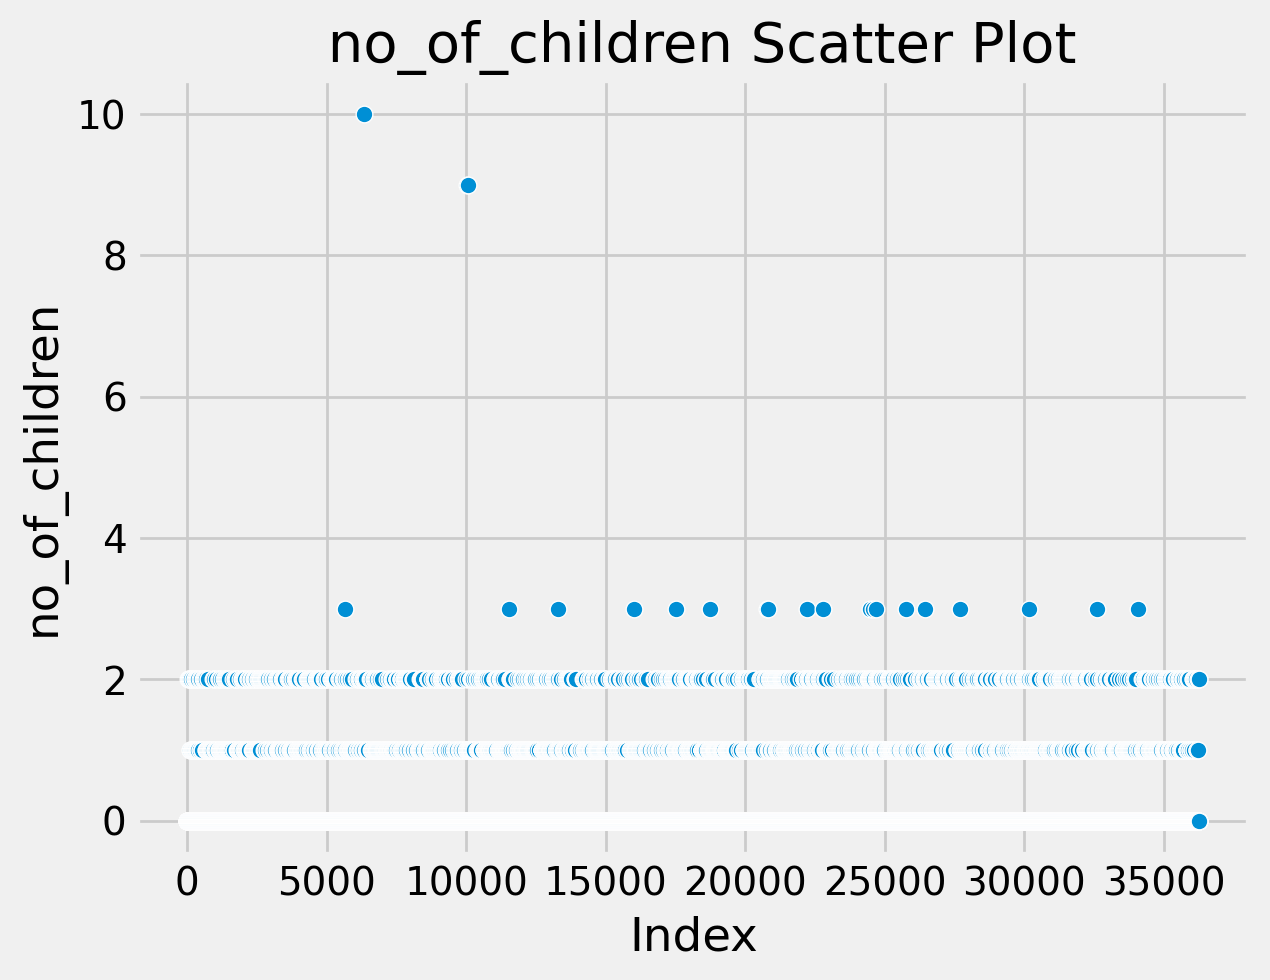

In [ ]:
#no_of_children 산점도
sns.scatterplot(x=range(len(df)), y=df['no_of_children'])
plt.title(' no_of_children Scatter Plot')
plt.xlabel('Index')
plt.ylabel('no_of_children')

In [ ]:
# no_of_children의 9,10 데이터가 이상치인지 확인
df[df["no_of_children"] > 5]

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
6338,INN06339,2,10,0,2,Meal Plan 1,0,Room_Type 4,37,2018,1,12,Online,0,0,0,84.45,1,Not_Canceled
10041,INN10042,1,9,2,1,Meal Plan 1,0,Room_Type 1,11,2017,10,11,Corporate,0,0,0,95.00,0,Not_Canceled
10061,INN10062,2,9,2,5,Meal Plan 1,0,Room_Type 2,8,2017,8,13,Online,0,0,0,76.50,1,Canceled


In [ ]:
# 가격을 보니 방을 2개 이상을 예약한 것 같진 않은데 한 방에서 10명 이상 숙박할 수 있는 방이 있나? 그렇다기엔 그러한 경우가 3개뿐 > 이상치로 봐도 괜찮지 않을까..?


In [ ]:
#no_of_children의 이상치 제거
drop_chil = df[df["no_of_children"] > 5].index
df.drop(drop_chil, inplace=True)

<Axes: ylabel='no_of_children'>

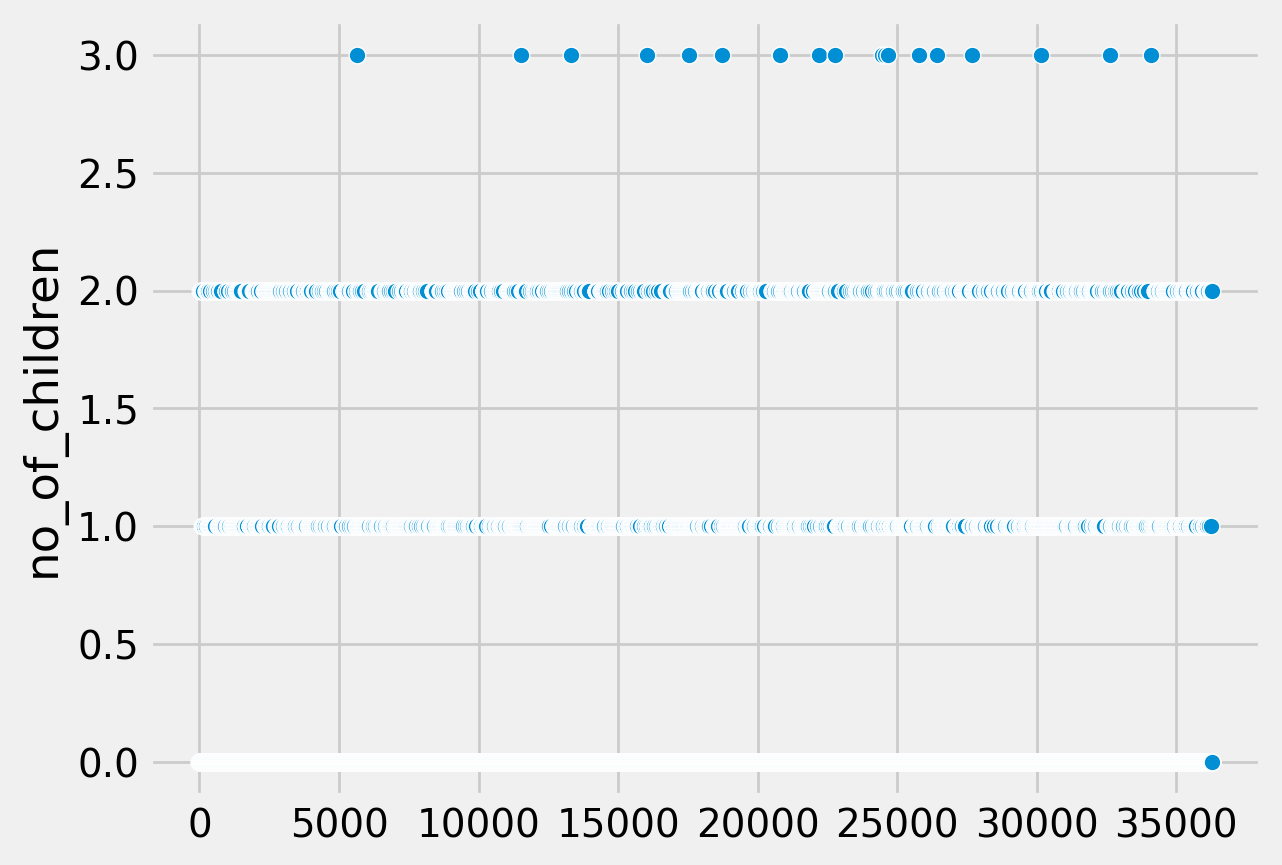

In [ ]:
sns.scatterplot(x=range(len(df)), y=df['no_of_children'])
# 이상치 제거됨

In [ ]:
# no_of_weekend_nights와 no_of_week_nights 모두 0인 경우가 있을까?
df[(df["no_of_weekend_nights"] == 0) & (df["no_of_week_nights"] == 0)]

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
209,INN00210,1,0,0,0,Meal Plan 1,0,Room_Type 1,4,2018,2,27,Complementary,0,0,0,0.0,1,Not_Canceled
1158,INN01159,2,0,0,0,Meal Plan 1,0,Room_Type 1,145,2018,7,5,Online,0,0,0,0.0,1,Not_Canceled
1403,INN01404,3,0,0,0,Meal Plan 1,0,Room_Type 4,57,2018,4,1,Online,0,0,0,0.0,2,Not_Canceled
1907,INN01908,2,0,0,0,Meal Plan 2,0,Room_Type 1,247,2018,6,6,Online,0,0,0,0.0,1,Not_Canceled
1986,INN01987,2,0,0,0,Meal Plan 1,0,Room_Type 1,43,2017,10,17,Online,0,0,0,0.0,1,Not_Canceled
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33218,INN33219,1,0,0,0,Meal Plan 1,0,Room_Type 1,1,2018,2,6,Online,0,0,0,0.0,0,Not_Canceled
33537,INN33538,2,0,0,0,Meal Plan 1,0,Room_Type 2,166,2018,4,21,Online,0,0,0,0.0,2,Not_Canceled
34750,INN34751,1,0,0,0,Meal Plan 1,0,Room_Type 4,1,2017,10,22,Complementary,0,0,0,0.0,0,Not_Canceled
35472,INN35473,1,0,0,0,Meal Plan 1,0,Room_Type 1,7,2018,2,15,Online,0,0,0,0.0,0,Not_Canceled


In [ ]:
# 주말과 평일 모두 머물지 않는다는 것 > 대실로 생각할 수 있음,

In [ ]:
df[(df["no_of_week_nights"] >5) & (df["no_of_weekend_nights"] <2)]

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status


In [ ]:
# no_of_adults와 no_of_week_children 모두 0인 경우가 있을까?
df[(df["no_of_adults"] == 0) & (df["no_of_children"] == 0)]
#없음

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status


In [ ]:
#그렇다면 어른이 없는데 아이들만 숙박한 경우는?
df[(df["no_of_adults"] == 0) & (df["no_of_children"] >= 1)]

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
32,INN00033,0,2,0,3,Meal Plan 1,0,Room_Type 2,56,2018,12,7,Online,0,0,0,82.44,1,Not_Canceled
287,INN00288,0,2,2,2,Meal Plan 1,0,Room_Type 1,68,2018,4,24,Online,0,0,0,108.38,1,Canceled
653,INN00654,0,2,1,2,Meal Plan 1,0,Room_Type 2,78,2018,8,19,Online,0,0,0,115.68,1,Not_Canceled
937,INN00938,0,2,0,3,Meal Plan 1,0,Room_Type 2,40,2018,1,14,Online,0,0,0,6.67,1,Not_Canceled
954,INN00955,0,2,1,1,Meal Plan 1,0,Room_Type 2,92,2018,10,29,Online,0,0,0,81.50,2,Not_Canceled
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34720,INN34721,0,2,0,3,Meal Plan 1,0,Room_Type 2,76,2018,9,21,Online,0,0,0,127.38,3,Not_Canceled
34730,INN34731,0,2,1,1,Meal Plan 1,0,Room_Type 2,178,2018,8,27,Online,0,0,0,88.77,0,Canceled
34890,INN34891,0,2,2,2,Meal Plan 1,0,Room_Type 2,31,2018,9,16,Online,0,0,0,124.25,2,Not_Canceled
35691,INN35692,0,2,2,1,Meal Plan 1,0,Room_Type 2,75,2018,3,19,Online,0,0,0,78.00,0,Canceled


In [ ]:
# 139개의 행으로 꽤 많은 데이터를 갖고 있음
# 찾아보니까 만 18세까지 children이라고 부름 > 청소년끼리도 이용할 수 있는 호텔인 걸로

In [ ]:
df[(df["no_of_week_nights"] >5) & (df["no_of_weekend_nights"] <2)]

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status


In [ ]:
# no_of_adults와 no_of_week_children 모두 0인 경우가 있을까?
df[(df["no_of_adults"] == 0) & (df["no_of_children"] == 0)]
#없음

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status


<Axes: xlabel='lead_time'>

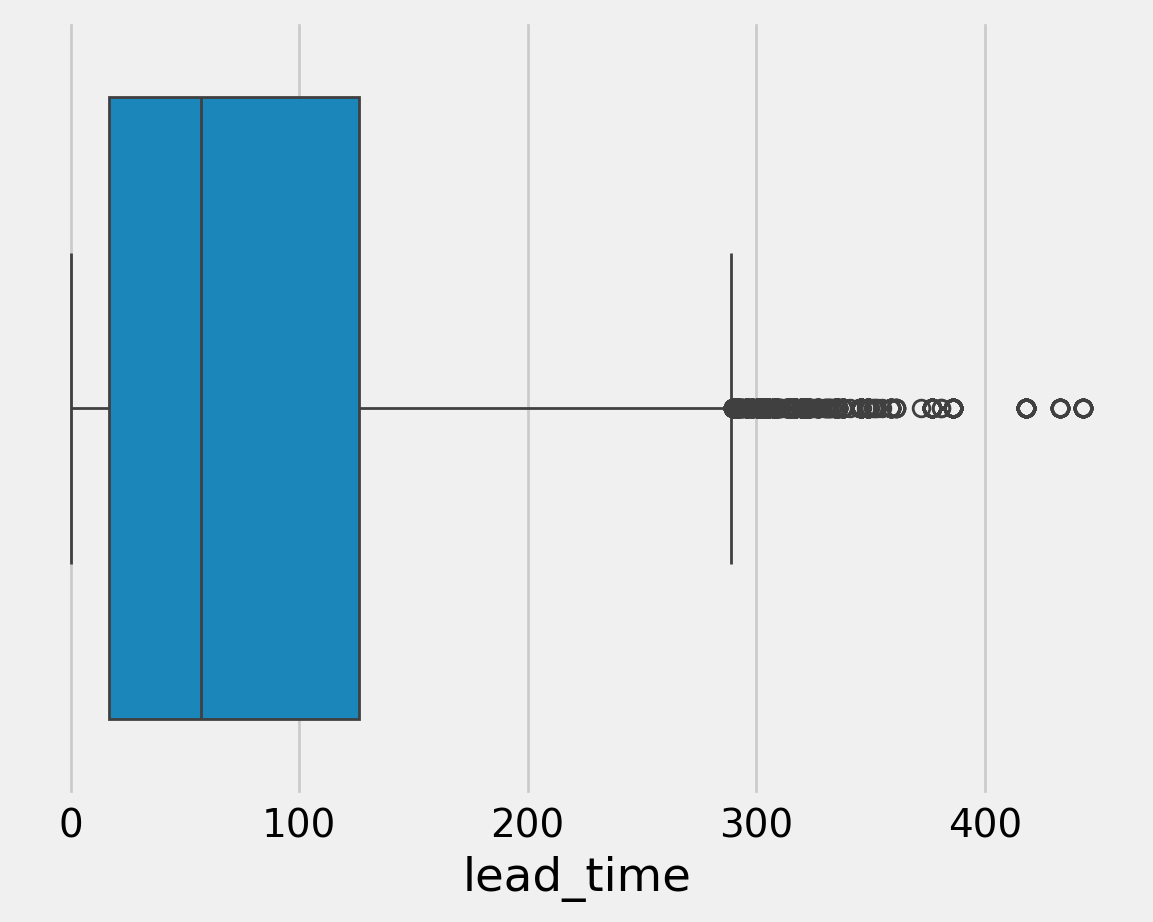

In [ ]:
sns.boxplot(x=df['lead_time'])

In [ ]:
df[(df["lead_time"] > 400) & (df["no_of_children"] == 0)]
#그냥 파워J들인건가 근데 모두 아이들이 없음

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
118,INN00119,2,0,0,1,Meal Plan 1,0,Room_Type 1,443,2018,4,29,Online,0,0,0,65.0,0,Canceled
199,INN00200,2,0,1,2,Meal Plan 2,0,Room_Type 1,418,2018,9,26,Online,0,0,0,107.0,0,Canceled
205,INN00206,2,0,0,3,Meal Plan 1,0,Room_Type 1,433,2018,9,8,Online,0,0,0,70.0,0,Canceled
963,INN00964,2,0,1,2,Meal Plan 2,0,Room_Type 1,418,2018,9,26,Online,0,0,0,107.0,0,Canceled
1116,INN01117,2,0,1,2,Meal Plan 2,0,Room_Type 1,418,2018,9,26,Online,0,0,0,107.0,0,Canceled
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35189,INN35190,2,0,1,2,Meal Plan 1,0,Room_Type 1,418,2018,9,26,Offline,0,0,0,75.0,0,Canceled
35241,INN35242,2,0,0,3,Meal Plan 1,0,Room_Type 1,433,2018,9,8,Offline,0,0,0,70.0,0,Canceled
35369,INN35370,2,0,1,2,Meal Plan 2,0,Room_Type 1,418,2018,9,26,Offline,0,0,0,107.0,0,Canceled
35594,INN35595,2,0,1,2,Meal Plan 2,0,Room_Type 1,418,2018,9,26,Offline,0,0,0,107.0,0,Canceled


In [ ]:
df[(df["lead_time"]==0)]

#당일예약인가보다 > 이상치 x

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
10,INN00011,1,0,1,0,Not Selected,0,Room_Type 1,0,2018,9,11,Online,0,0,0,85.03,0,Not_Canceled
16,INN00017,1,0,1,0,Meal Plan 1,0,Room_Type 1,0,2017,10,5,Offline,0,0,0,96.00,0,Not_Canceled
107,INN00108,2,0,1,3,Meal Plan 1,0,Room_Type 4,0,2017,9,21,Online,0,0,0,155.00,1,Not_Canceled
159,INN00160,2,0,1,0,Not Selected,0,Room_Type 1,0,2018,6,5,Online,0,0,0,109.00,0,Not_Canceled
220,INN00221,1,0,0,2,Not Selected,0,Room_Type 1,0,2018,6,8,Online,0,0,0,109.00,1,Not_Canceled
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36133,INN36134,3,0,0,1,Meal Plan 1,0,Room_Type 4,0,2018,8,23,Online,0,0,0,225.00,2,Not_Canceled
36169,INN36170,1,0,2,4,Meal Plan 1,0,Room_Type 1,0,2018,9,4,Offline,0,0,0,85.00,1,Not_Canceled
36204,INN36205,2,0,0,1,Not Selected,0,Room_Type 1,0,2017,12,24,Online,0,0,0,85.00,0,Not_Canceled
36216,INN36217,2,0,1,1,Not Selected,0,Room_Type 1,0,2018,8,27,Online,0,0,0,149.00,0,Not_Canceled


<Axes: ylabel='no_of_previous_cancellations'>

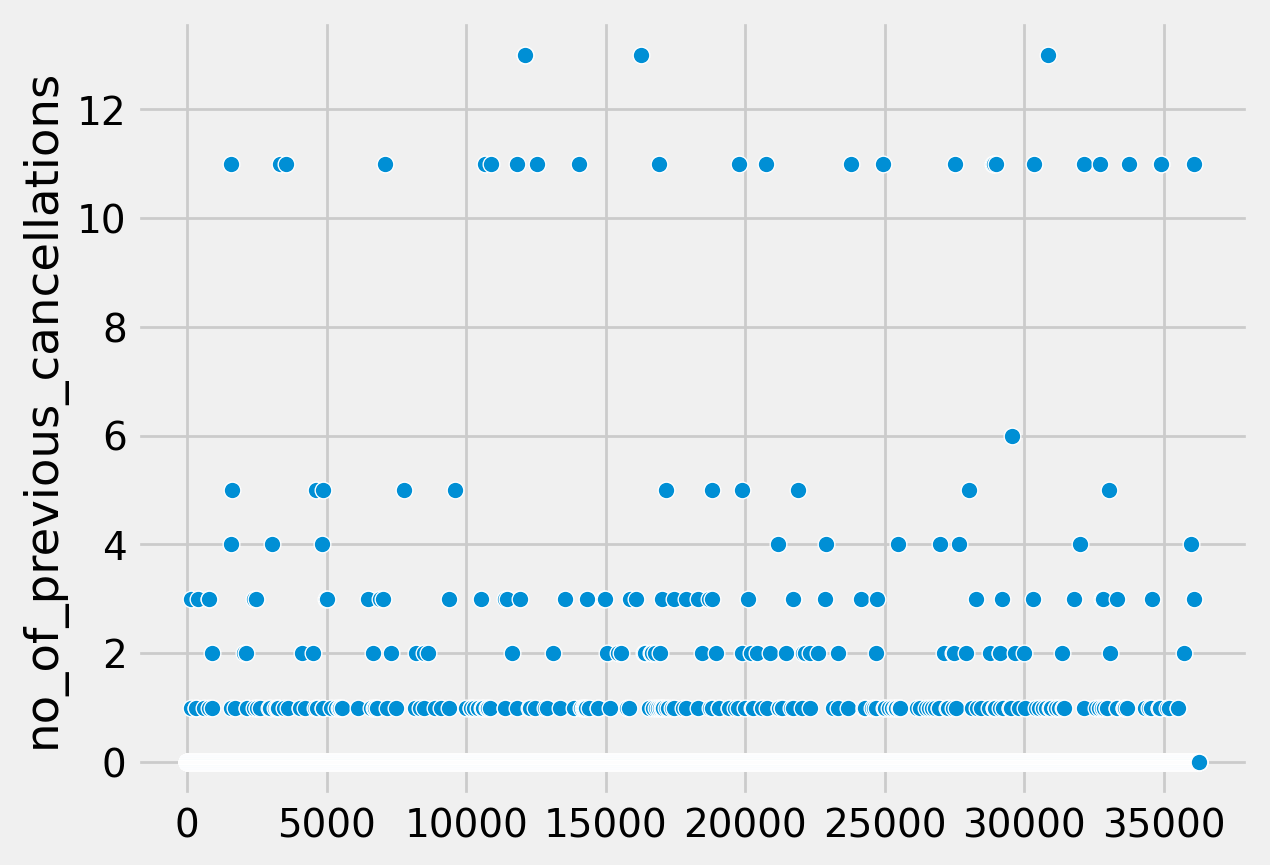

In [ ]:
sns.scatterplot(x=range(len(df)), y=df['no_of_previous_cancellations'])

In [ ]:
df[df['no_of_previous_cancellations'] > 12]
# id를 제외한 모든 컬럼이 동일함.
# 1. 우연의 일치다  /   2.  항상 같이 여행을 다니는 일행이다 / 3. 이상치이다.

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
12097,INN12098,2,0,1,1,Meal Plan 1,0,Room_Type 1,190,2018,4,9,Offline,1,13,1,70.0,0,Canceled
12109,INN12110,2,0,1,1,Meal Plan 1,0,Room_Type 1,190,2018,4,9,Offline,1,13,1,70.0,0,Canceled
16277,INN16278,2,0,1,1,Meal Plan 1,0,Room_Type 1,190,2018,4,9,Offline,1,13,1,70.0,0,Canceled
30833,INN30834,2,0,1,1,Meal Plan 1,0,Room_Type 1,190,2018,4,9,Offline,1,13,1,70.0,0,Canceled


In [ ]:
df[df['no_of_previous_cancellations'] > 10]
# 이 데이터로 확인해봤을 때 완벽하게 일치하는 데이터는 위의 데이터밖에 없기 때문에 이상치로 판정.

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
1561,INN01562,2,0,0,1,Meal Plan 1,0,Room_Type 1,0,2018,1,14,Online,1,11,4,81.90,0,Not_Canceled
3322,INN03323,2,0,0,1,Meal Plan 1,0,Room_Type 4,5,2018,1,15,Online,1,11,5,89.30,1,Not_Canceled
3530,INN03531,2,0,0,1,Not Selected,1,Room_Type 1,2,2018,1,16,Online,1,11,10,86.00,1,Not_Canceled
7110,INN07111,2,0,0,1,Not Selected,0,Room_Type 1,10,2018,2,13,Online,1,11,22,79.00,1,Not_Canceled
10686,INN10687,2,0,0,2,Not Selected,0,Room_Type 1,1,2018,2,12,Online,1,11,22,79.00,1,Not_Canceled
10890,INN10891,2,0,0,1,Not Selected,0,Room_Type 1,1,2018,1,15,Online,1,11,5,75.00,0,Not_Canceled
11834,INN11835,2,0,0,2,Not Selected,1,Room_Type 1,1,2018,1,8,Online,1,11,0,76.50,0,Not_Canceled
12097,INN12098,2,0,1,1,Meal Plan 1,0,Room_Type 1,190,2018,4,9,Offline,1,13,1,70.00,0,Canceled
12109,INN12110,2,0,1,1,Meal Plan 1,0,Room_Type 1,190,2018,4,9,Offline,1,13,1,70.00,0,Canceled
12554,INN12555,2,0,0,1,Meal Plan 1,0,Room_Type 1,3,2018,1,14,Online,1,11,4,83.90,1,Not_Canceled


In [ ]:
drop_no_prev_can = df[df['no_of_previous_cancellations'] > 12].index
df.drop(drop_no_prev_can, inplace=True)

<Axes: ylabel='no_of_previous_bookings_not_canceled'>

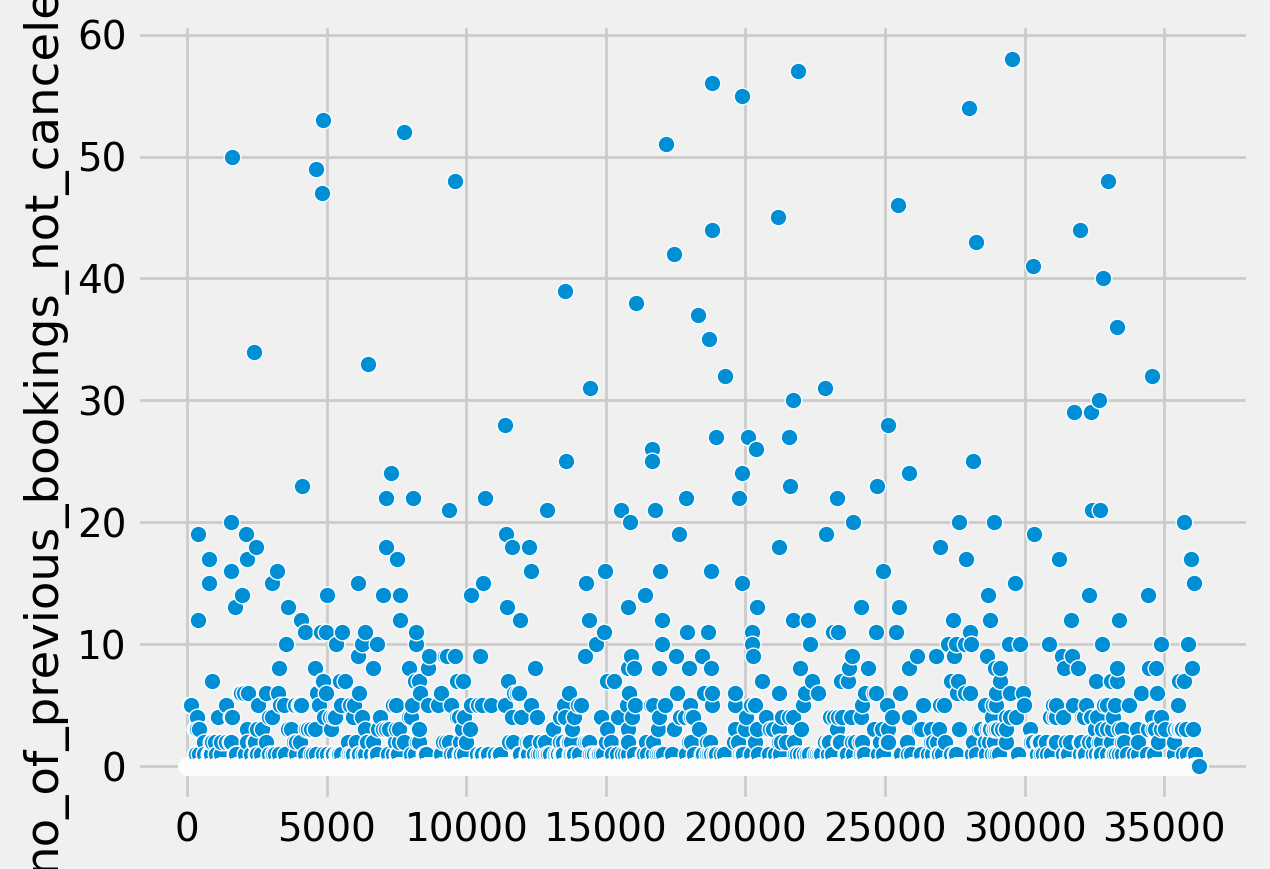

In [ ]:
sns.scatterplot(x=range(len(df)), y=df['no_of_previous_bookings_not_canceled'])

In [ ]:
print(df['no_of_previous_bookings_not_canceled'].head())

0    0
1    0
2    0
3    0
4    0
Name: no_of_previous_bookings_not_canceled, dtype: int64


In [ ]:
df[df["no_of_previous_bookings_not_canceled"] > 40]
# 이 사람들은 재방문횟수가 적어도 40번 이상이라는 것 >> 여기서 문제1번의 해답을 찾을 수 있을지도?
# 총 20개의 행

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
1626,INN01627,1,0,2,6,Meal Plan 1,0,Room_Type 1,7,2018,11,2,Corporate,1,5,50,65.0,0,Not_Canceled
4603,INN04604,1,0,1,2,Meal Plan 1,0,Room_Type 1,4,2018,10,24,Corporate,1,5,49,65.0,2,Not_Canceled
4828,INN04829,1,0,1,3,Meal Plan 1,0,Room_Type 1,3,2018,10,10,Corporate,1,4,47,65.0,1,Not_Canceled
4864,INN04865,1,0,1,2,Meal Plan 1,0,Room_Type 1,2,2018,11,28,Corporate,1,5,53,65.0,2,Not_Canceled
7787,INN07788,1,0,2,3,Meal Plan 1,0,Room_Type 1,3,2018,11,20,Corporate,1,5,52,65.0,2,Not_Canceled
9608,INN09609,1,0,0,1,Meal Plan 1,0,Room_Type 1,9,2018,10,19,Corporate,1,5,48,65.0,0,Not_Canceled
17175,INN17176,1,0,2,1,Meal Plan 1,0,Room_Type 1,3,2018,11,13,Corporate,1,5,51,65.0,1,Not_Canceled
17451,INN17452,1,0,1,2,Meal Plan 1,0,Room_Type 1,0,2018,8,29,Corporate,1,3,42,65.0,0,Not_Canceled
18794,INN18795,1,0,0,2,Meal Plan 1,1,Room_Type 1,7,2018,12,14,Corporate,1,5,56,67.0,2,Not_Canceled
18822,INN18823,1,0,1,2,Meal Plan 1,0,Room_Type 1,3,2018,9,12,Corporate,1,3,44,67.0,0,Not_Canceled


In [ ]:
# df[df["no_of_previous_bookings_not_canceled"] > 40]의 공통점
# no_of_children == 0, & segment가 corportate인것으로 보아 출장일 가능성 多
# lead_time이 모두 비교적 짧음 / 주로 말년에 많이 방문(8월~)  / room type과 가격이 거의 통일되어있음


In [ ]:
df[df["no_of_children"] >= 8]

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status


<Axes: ylabel='no_of_children'>

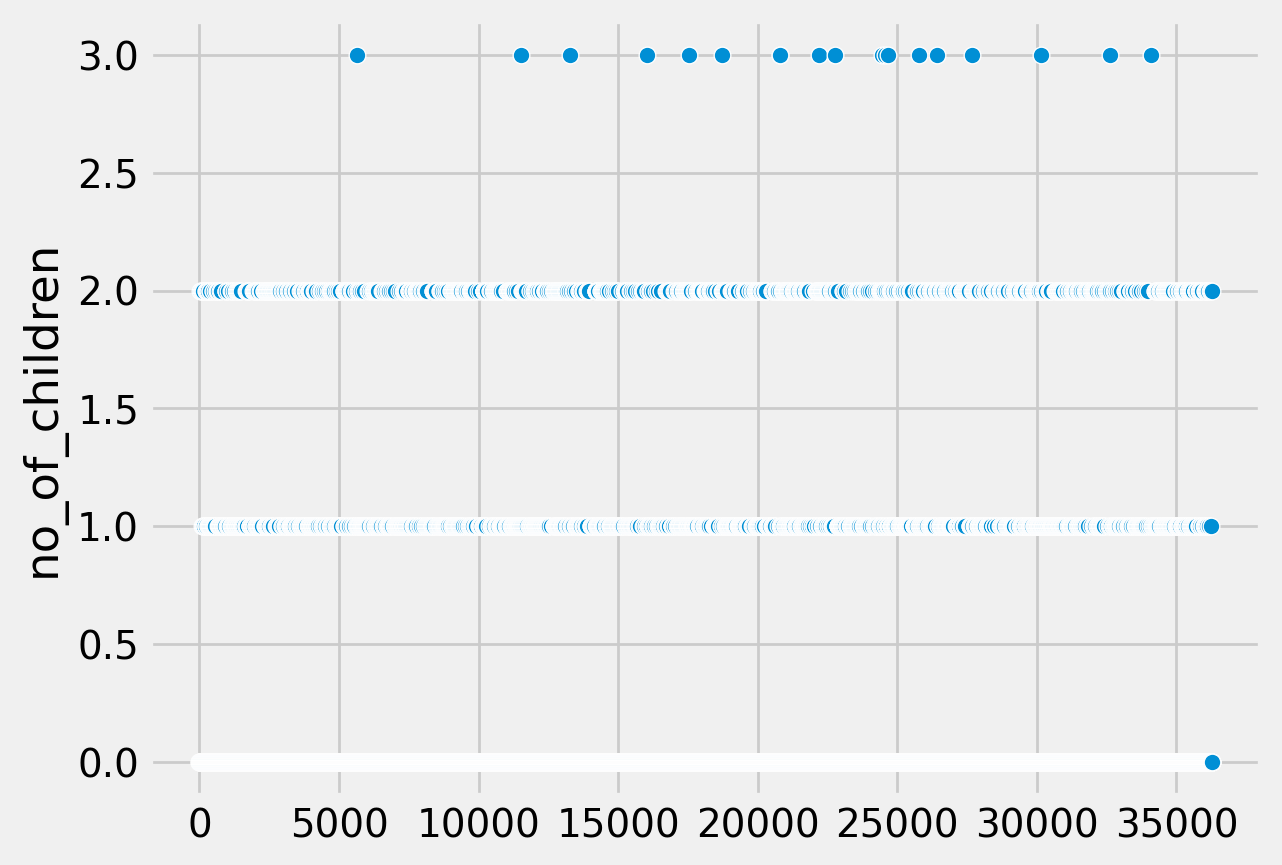

In [ ]:
#no_of_children의 이상치 제거
drop_chil = df[df["no_of_children"] > 5].index
df.drop(drop_chil, inplace=True)
sns.scatterplot(x=range(len(df)), y=df['no_of_children'])

In [ ]:
df.shape

(36268, 19)

In [ ]:
df[df["no_of_weekend_nights"]>=7]

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
19512,INN19513,2,0,7,17,Meal Plan 1,0,Room_Type 1,188,2018,7,4,Online,0,0,0,90.95,1,Canceled


주말 7일 투숙자는 평일도 17일 숙박했으므로 이상치 x

In [ ]:
df[df["avg_price_per_room"]>=500]

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
33114,INN33115,2,0,0,1,Meal Plan 1,0,Room_Type 1,35,2018,3,25,Offline,0,0,0,540.0,0,Canceled


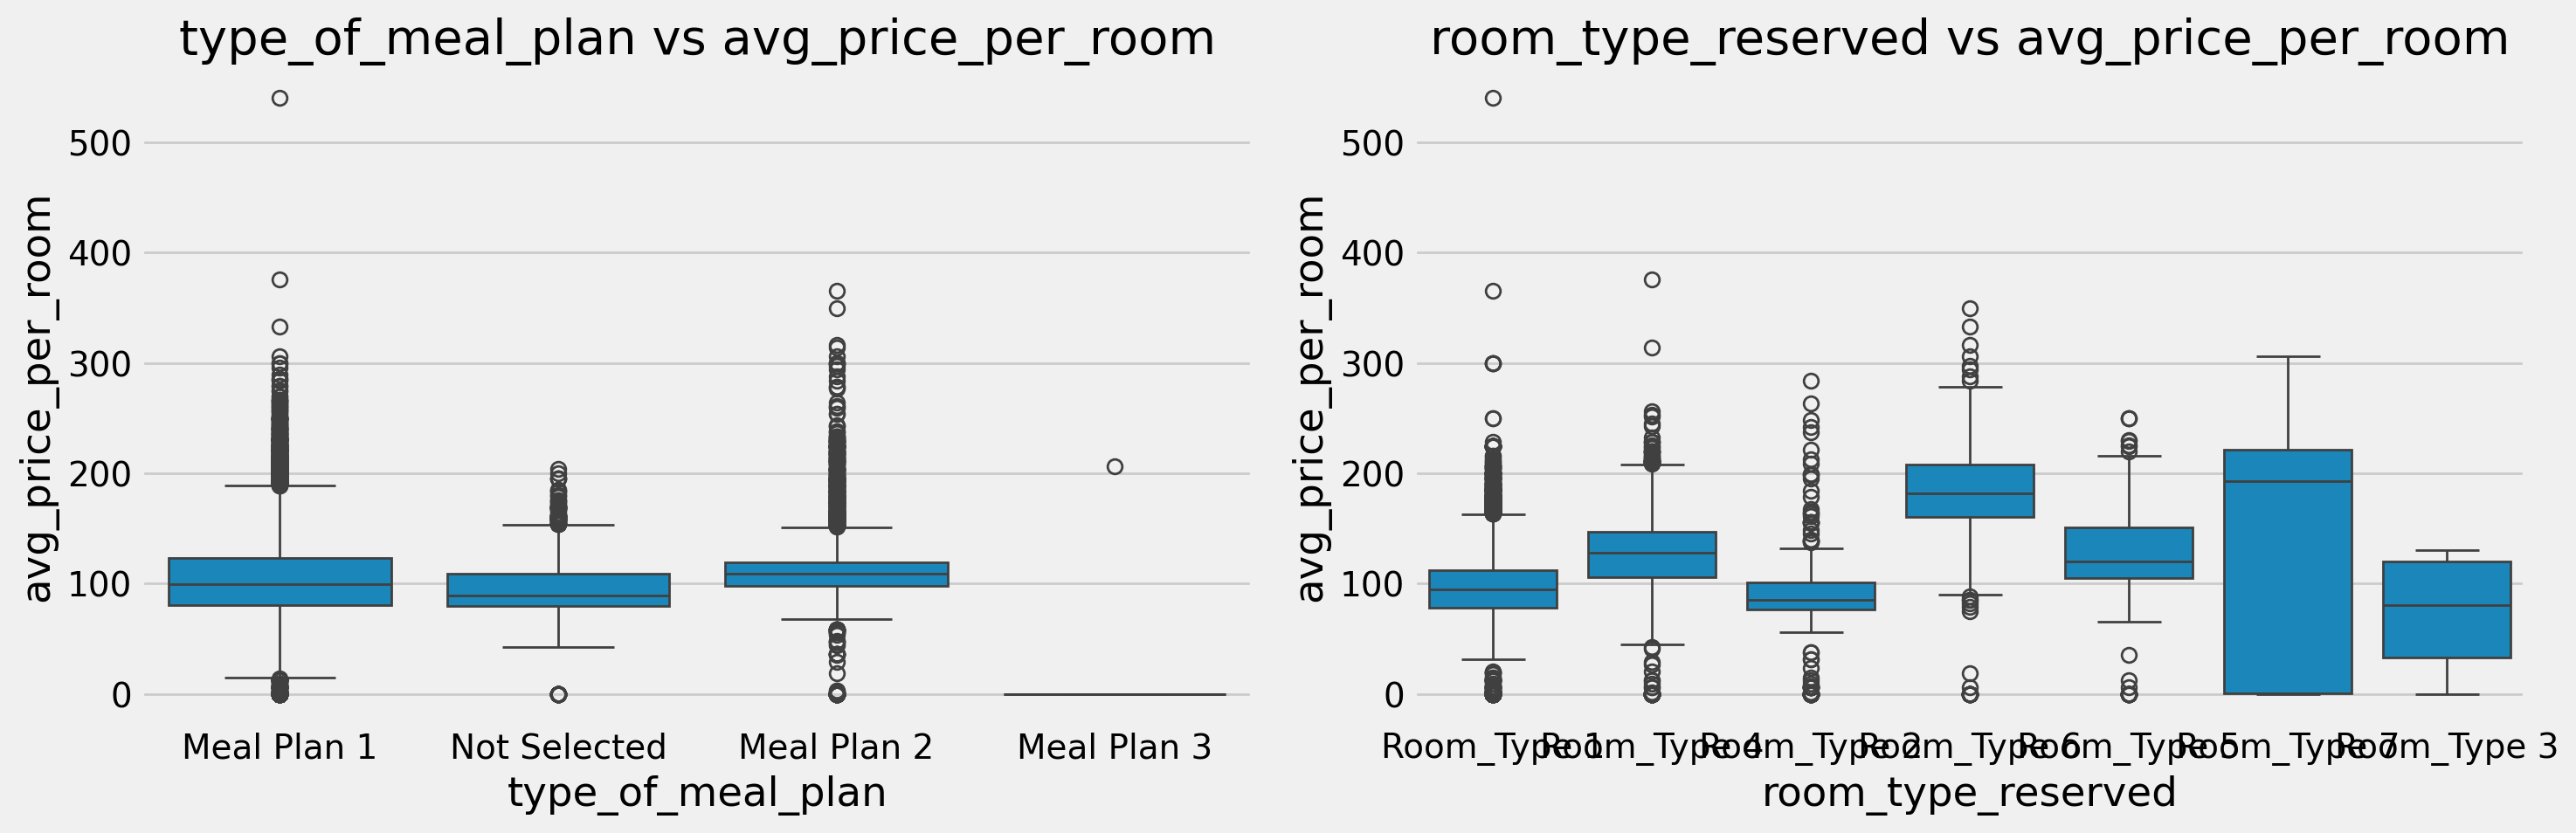

In [ ]:

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 왼쪽 서브플롯: type_of_meal_plan vs avg_price_per_room
sns.boxplot(data=df, x="type_of_meal_plan", y="avg_price_per_room", ax=axes[0])
axes[0].set_title("type_of_meal_plan vs avg_price_per_room")

# 오른쪽 서브플롯: room_type_reserved vs avg_price_per_room
sns.boxplot(data=df, x="room_type_reserved", y="avg_price_per_room", ax=axes[1])
axes[1].set_title("room_type_reserved vs avg_price_per_room")

plt.tight_layout()
plt.show()


<Axes: ylabel='avg_price_per_room'>

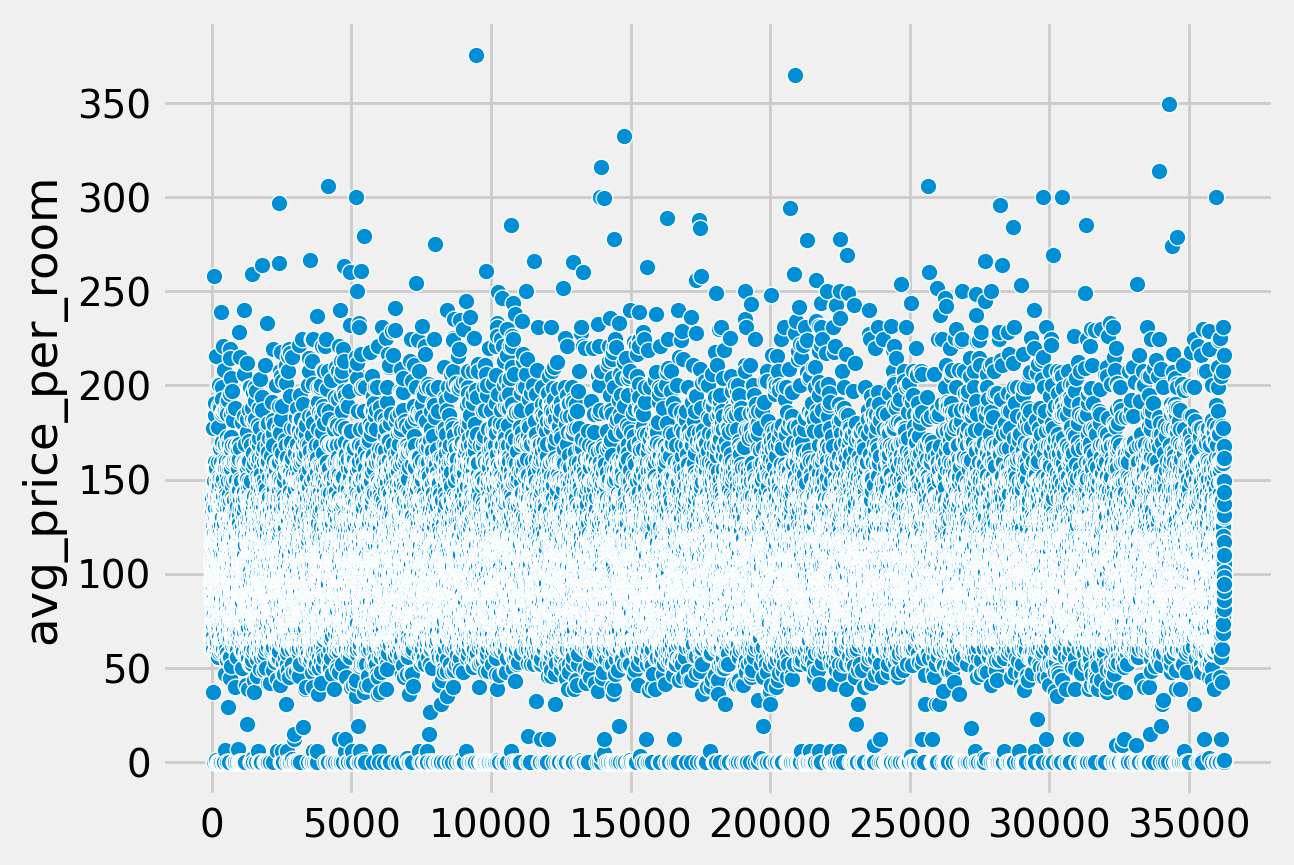

In [ ]:
# avg_price_per_room >= 500 인 데이터는 아무래도 이상치인 것 같아서 제거
drop_price = df[df["avg_price_per_room"] >=500].index
df.drop(drop_price, inplace=True)
sns.scatterplot(x=range(len(df)), y=df['avg_price_per_room'])

In [ ]:
df[df["avg_price_per_room"]== 0]

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
63,INN00064,1,0,0,1,Meal Plan 1,0,Room_Type 1,2,2017,9,10,Complementary,0,0,0,0.0,1,Not_Canceled
145,INN00146,1,0,0,2,Meal Plan 1,0,Room_Type 1,13,2018,6,1,Complementary,1,3,5,0.0,1,Not_Canceled
209,INN00210,1,0,0,0,Meal Plan 1,0,Room_Type 1,4,2018,2,27,Complementary,0,0,0,0.0,1,Not_Canceled
266,INN00267,1,0,0,2,Meal Plan 1,0,Room_Type 1,1,2017,8,12,Complementary,1,0,1,0.0,1,Not_Canceled
267,INN00268,1,0,2,1,Meal Plan 1,0,Room_Type 1,4,2017,8,23,Complementary,0,0,0,0.0,1,Not_Canceled
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35983,INN35984,1,0,0,1,Meal Plan 1,0,Room_Type 7,0,2018,6,7,Complementary,1,4,17,0.0,1,Not_Canceled
36080,INN36081,1,0,1,1,Meal Plan 1,0,Room_Type 7,0,2018,3,21,Complementary,1,3,15,0.0,1,Not_Canceled
36114,INN36115,1,0,0,1,Meal Plan 1,0,Room_Type 1,1,2018,3,2,Online,0,0,0,0.0,0,Not_Canceled
36217,INN36218,2,0,2,1,Meal Plan 1,0,Room_Type 2,3,2017,8,9,Online,0,0,0,0.0,2,Not_Canceled


In [ ]:
# df[df["avg_price_per_room"]>== 0] 을 확인해봤을 때 complementary 와 online 의 경로가 많아서 할인받은 것으로 간주하기로 함 -> 이상치 x

# EDA

##시각화

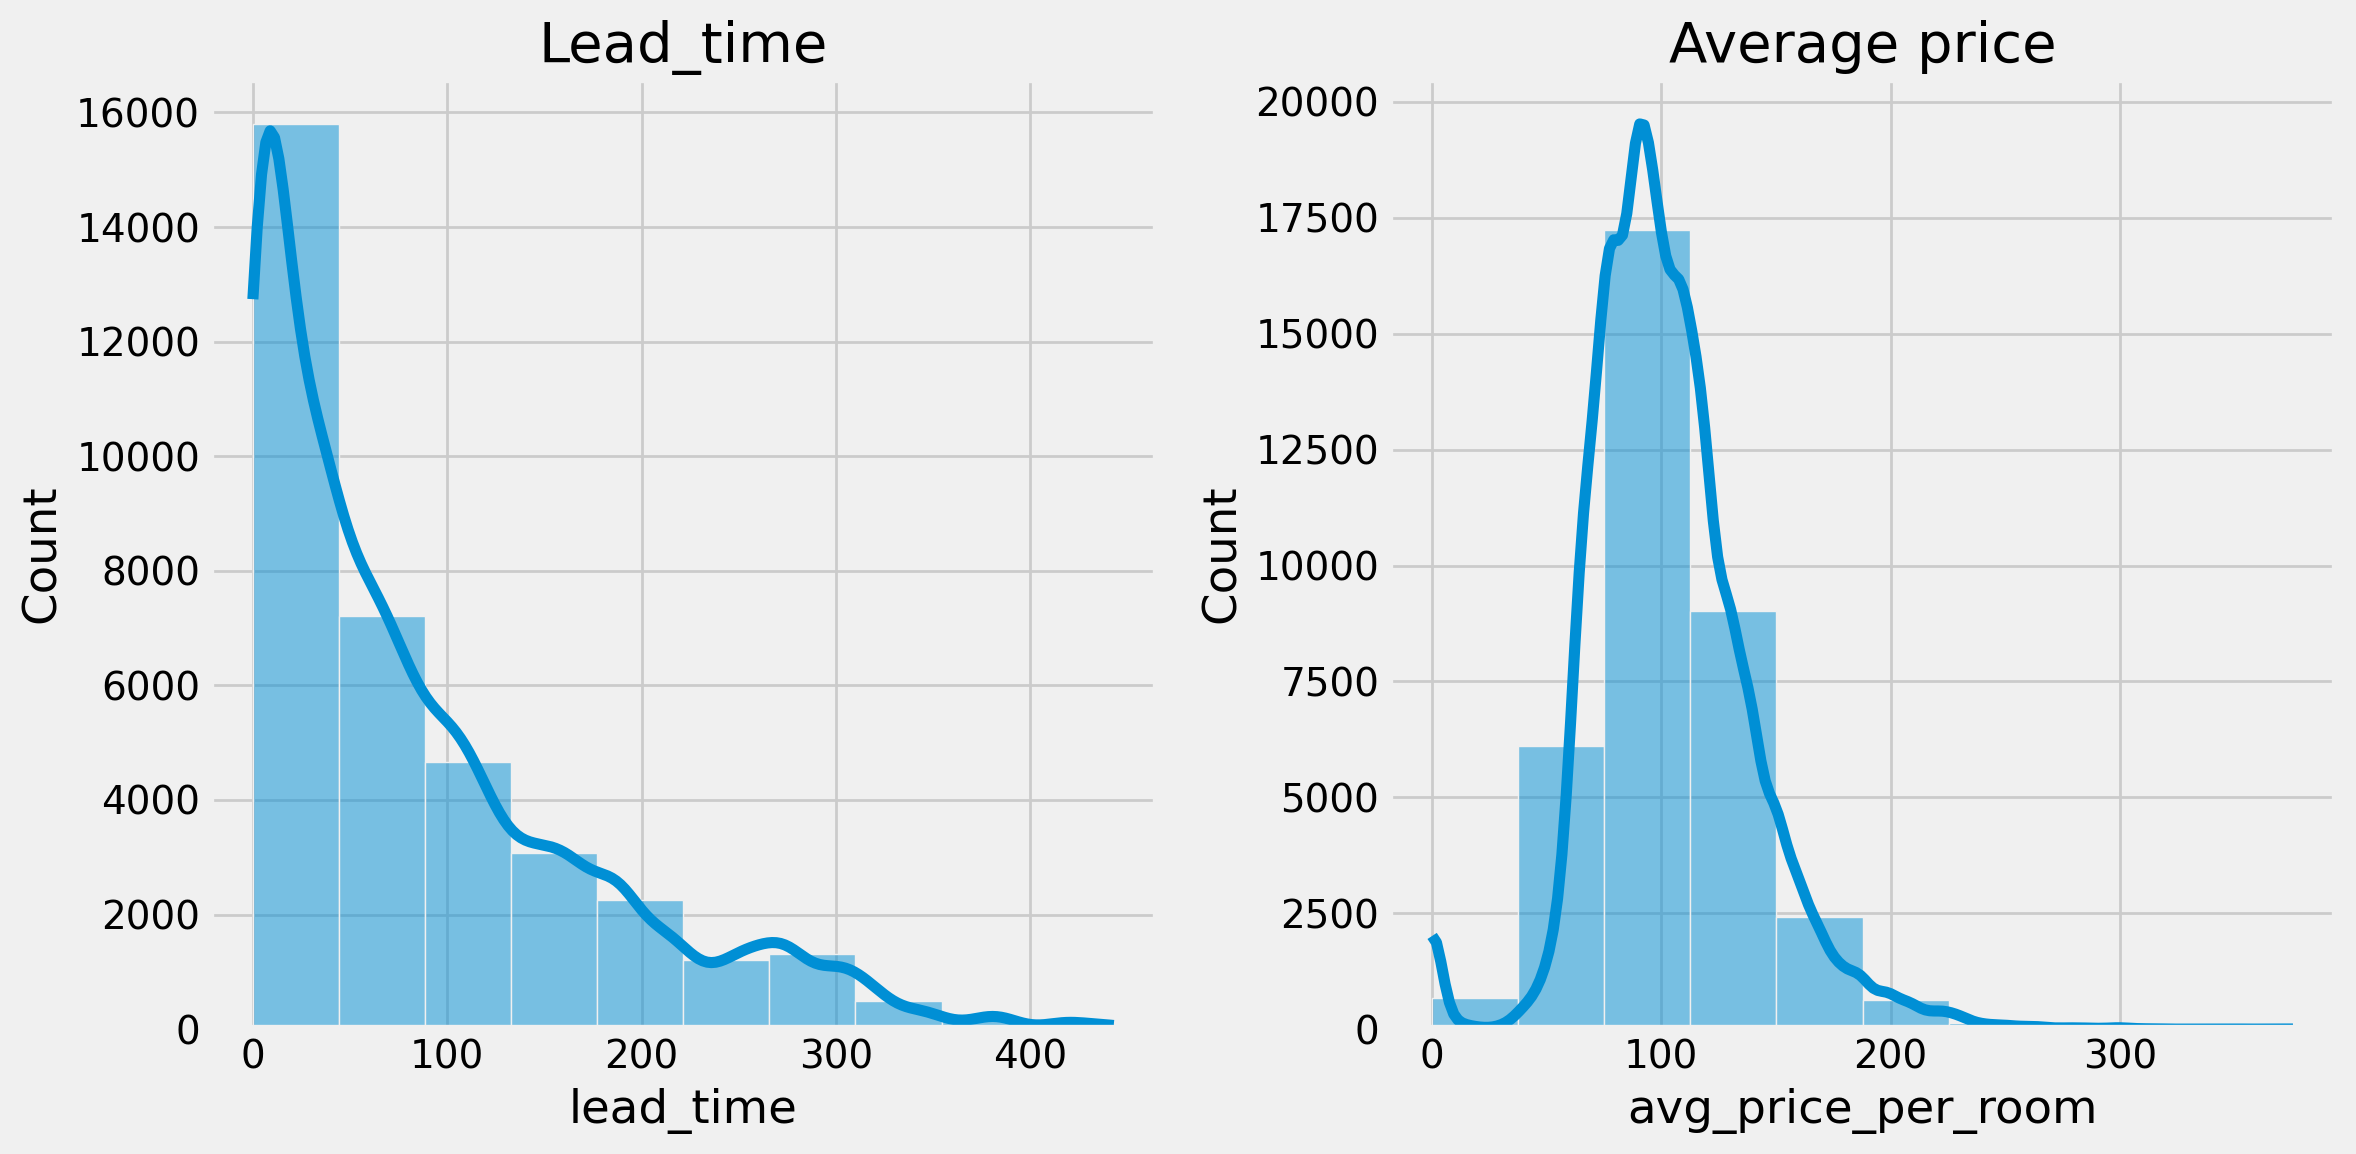

In [ ]:
# 연속형 변수의 분포 확인 (Lead_time, Price)
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['lead_time'], kde=True, bins=10)
plt.title('Lead_time')

plt.subplot(1, 2, 2)
sns.histplot(df['avg_price_per_room'], kde=True, bins=10)
plt.title('Average price')

plt.tight_layout()
plt.show()

#price는 거의 정규분포적 모습인듯?

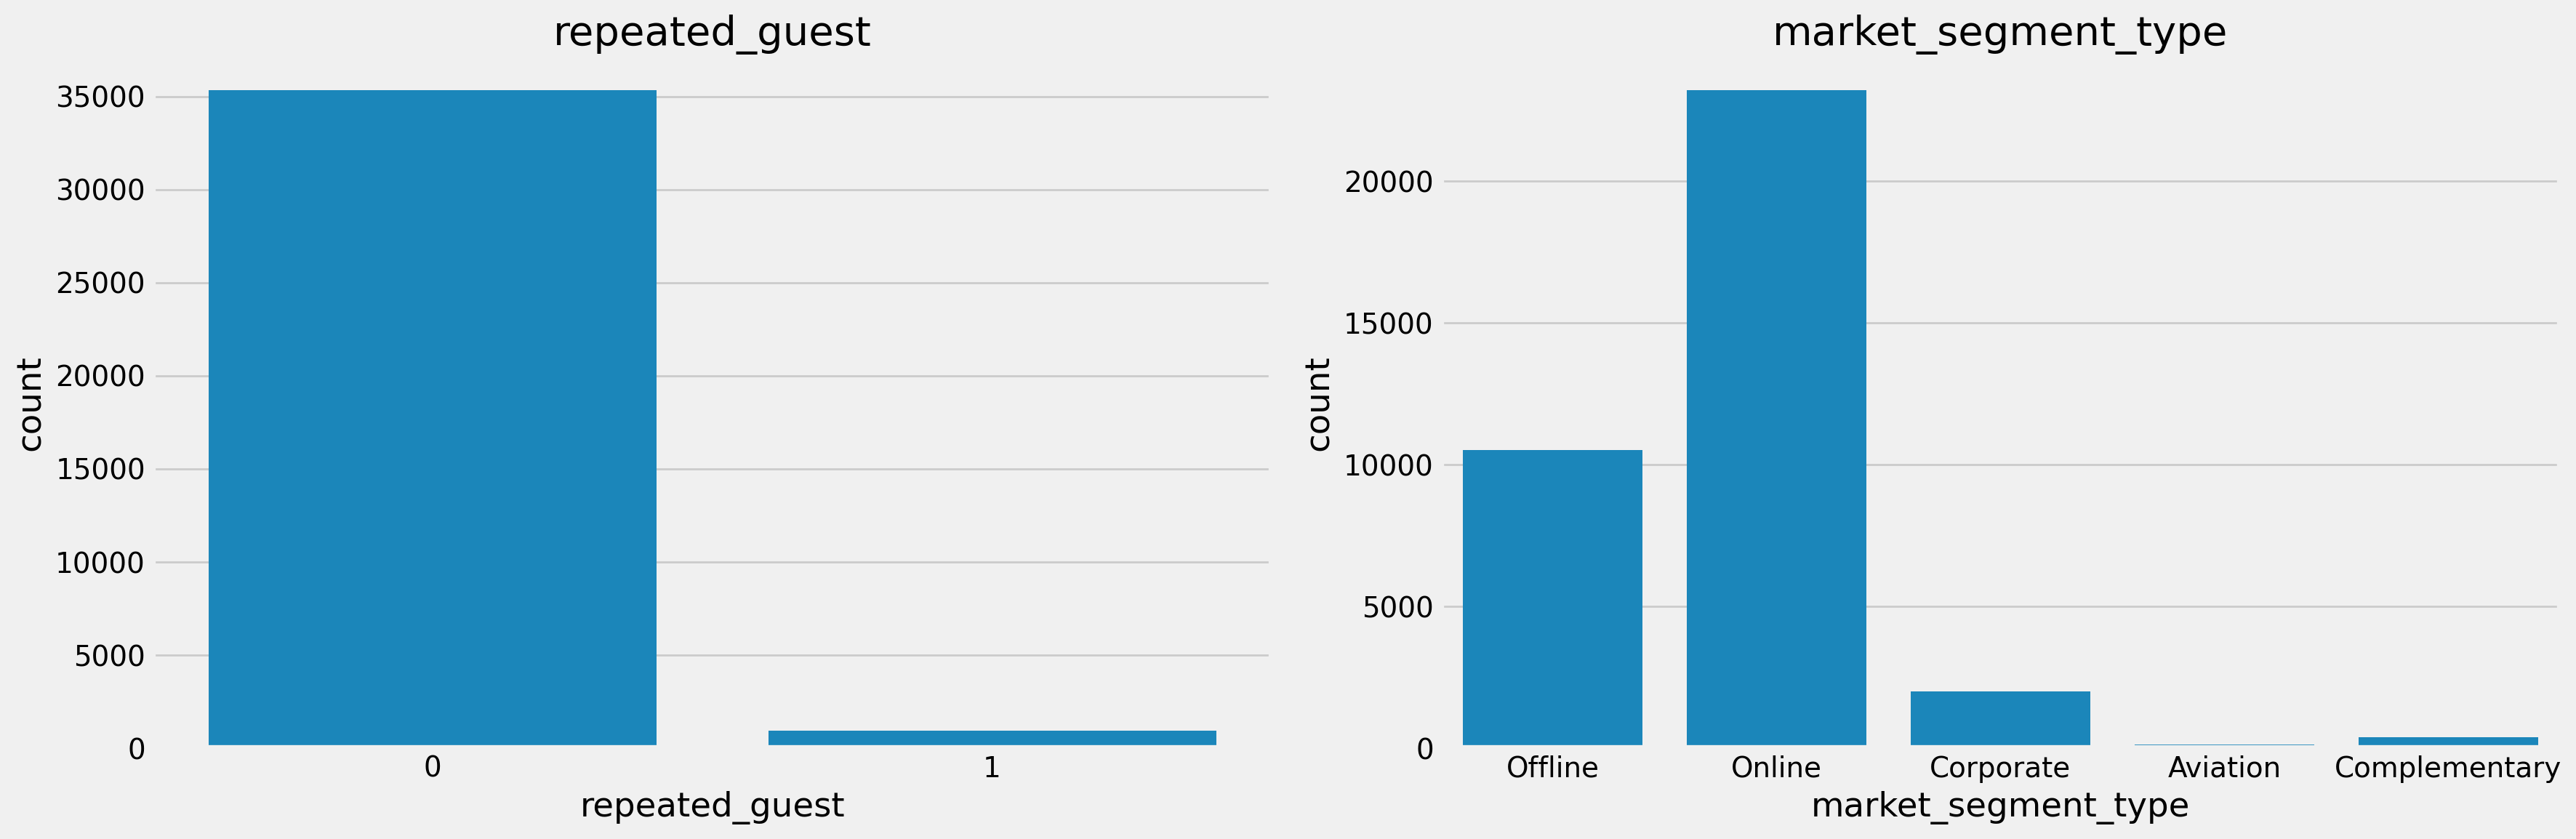

In [ ]:
# 범주형 변수의 분포 확인 (repeated_guest, room_type_reserved, marekt_segment_type)
plt.figure(figsize=(18, 6))

plt.subplot(1, 2, 1)
sns.countplot(x='repeated_guest', data=df)
plt.title('repeated_guest')

plt.subplot(1, 2, 2)
sns.countplot(x='market_segment_type', data=df)
plt.title('market_segment_type')

plt.tight_layout()
plt.show()

# 재방문 고객 비율이 현~~~~~~저히 적음 >> 문제!!
# Online에서 구매하는 고객이 특히 많음.
# 가설) market segment에 따라 재방문율 & 취소율이 달라질까?


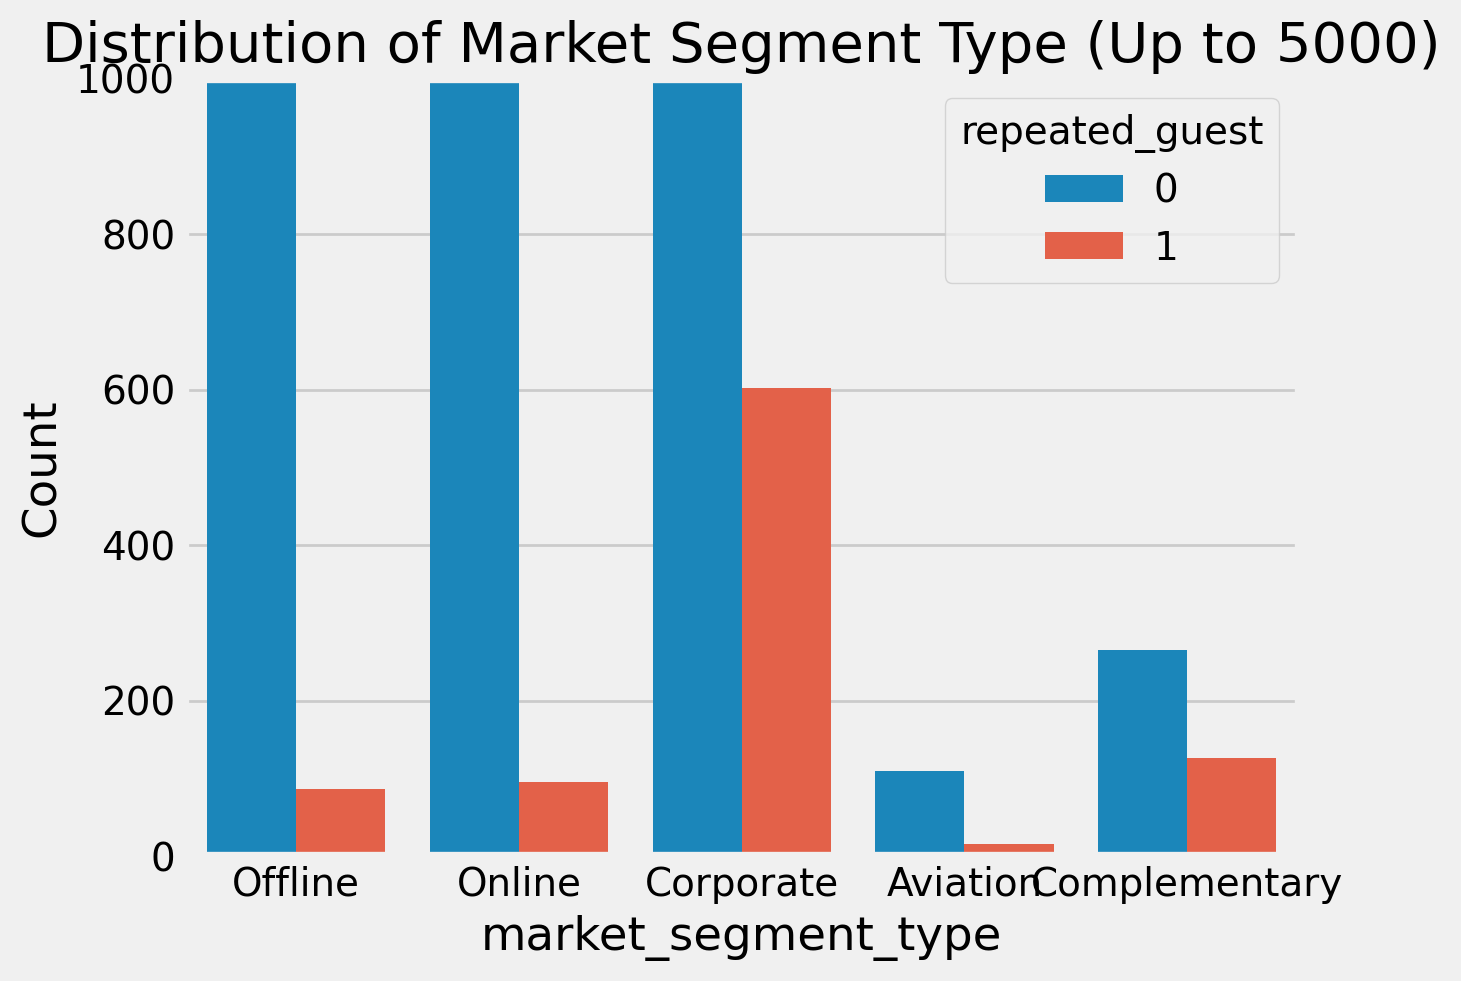

In [ ]:
sns.countplot(data=df, x='market_segment_type', hue='repeated_guest')
plt.title('Distribution of Market Segment Type (Up to 5000)')
plt.xlabel('market_segment_type')
plt.ylabel('Count')
plt.ylim(0, 1000)  # y축 범위를 0에서 1000으로 제한
plt.legend(title='repeated_guest')
plt.show()

# corporate의 경로로 예약한 사람들의 재방문율이 가장 높음을 알 수 있음

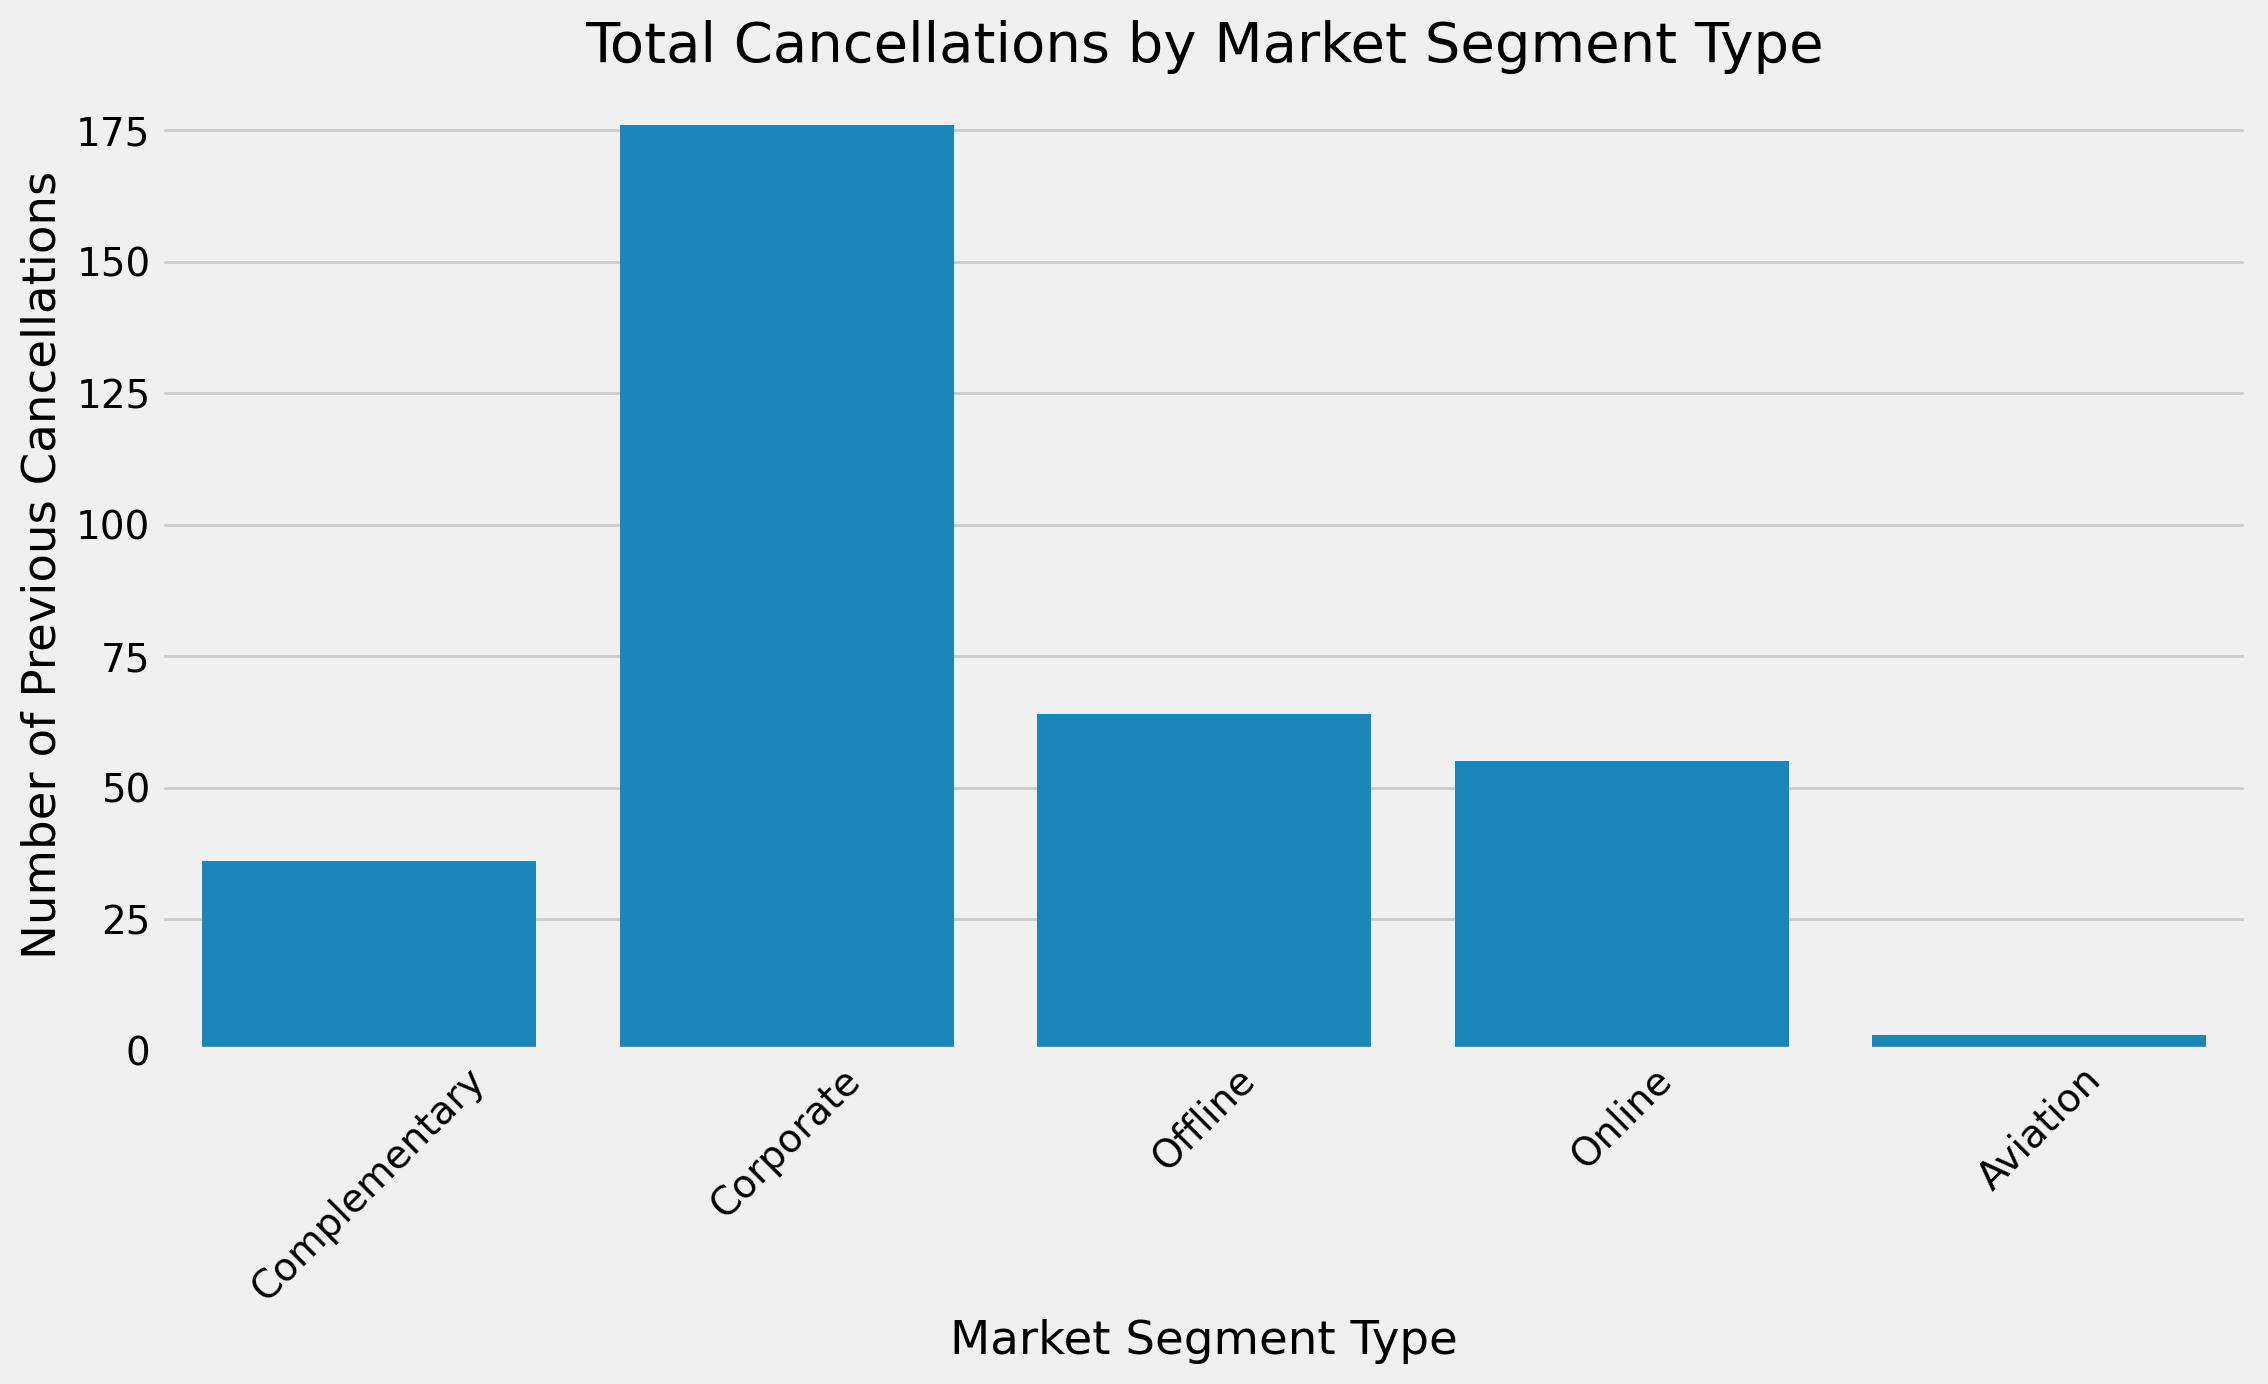

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 그래프 크기 설정
plt.figure(figsize=(12, 6))

# market_segment_type별 총 취소 횟수를 계산하기 위해 데이터 준비
df_cancel = df[df['no_of_previous_cancellations'] > 0]

# countplot으로 market_segment_type별 취소 횟수 시각화
sns.countplot(x='market_segment_type', data=df_cancel)

plt.title('Total Cancellations by Market Segment Type')
plt.xlabel('Market Segment Type')
plt.ylabel('Number of Previous Cancellations')

# x축 레이블을 45도 회전
plt.xticks(rotation=45)

plt.show()

# corporate의 경로로 예약한 사람들이 이전의 예약 취소 횟수도 가장 높음. 왜??????

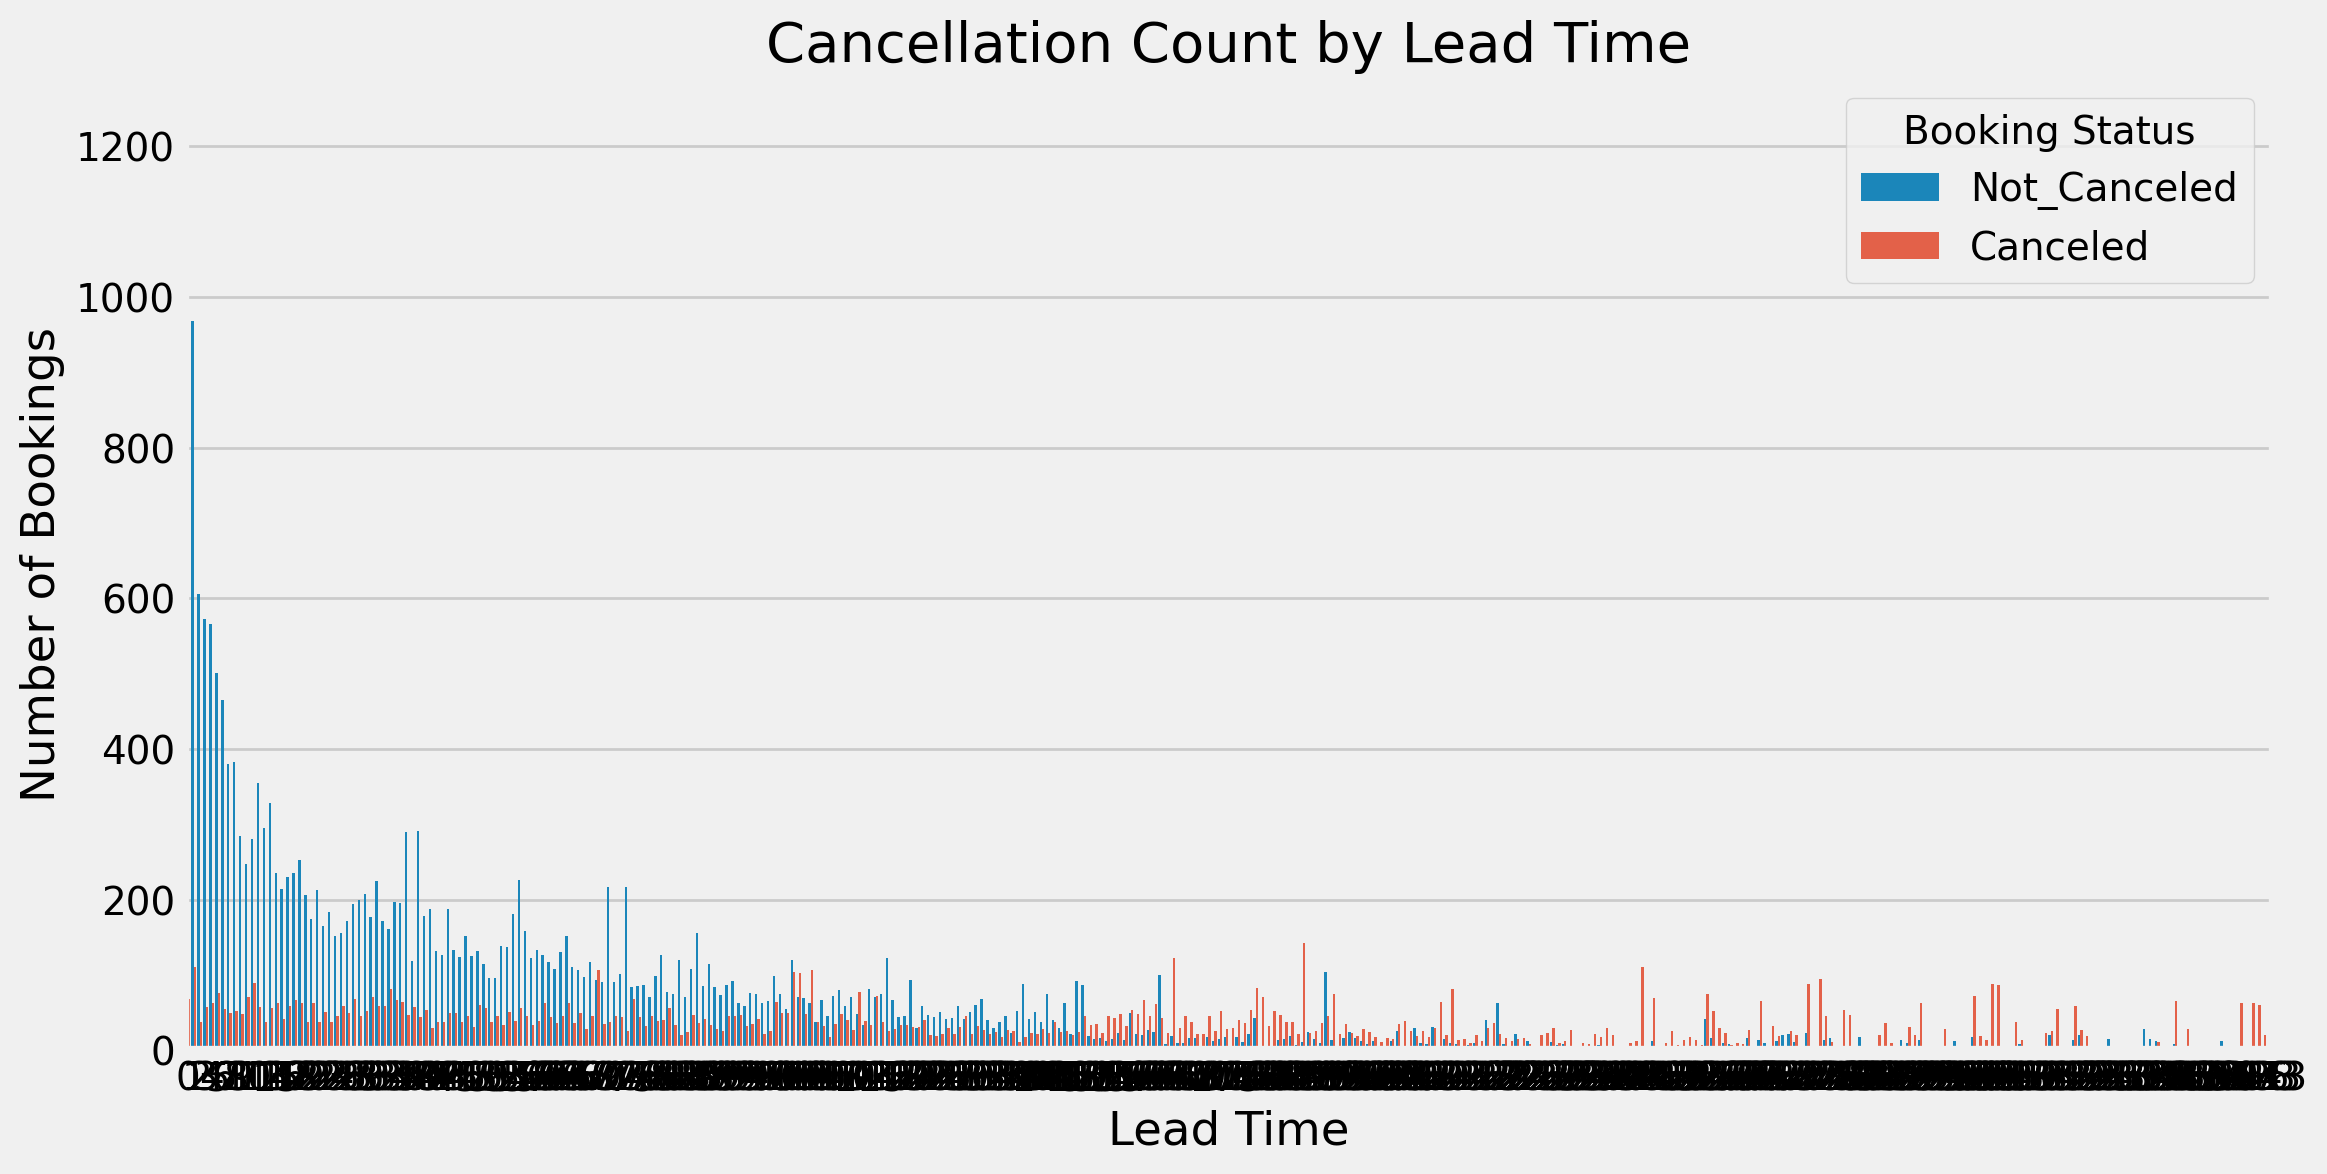

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 그래프 크기 설정
plt.figure(figsize=(12, 6))

# leadtime과 booking_status에 따른 countplot
sns.countplot(x='lead_time', hue='booking_status', data=df)

plt.title('Cancellation Count by Lead Time')
plt.xlabel('Lead Time')
plt.ylabel('Number of Bookings')
plt.legend(title='Booking Status')

plt.show()

# lead_time이 길어질수록 not_canceled의 비율이 감소

Text(0, 0.5, 'no_of_previous_cancellations')

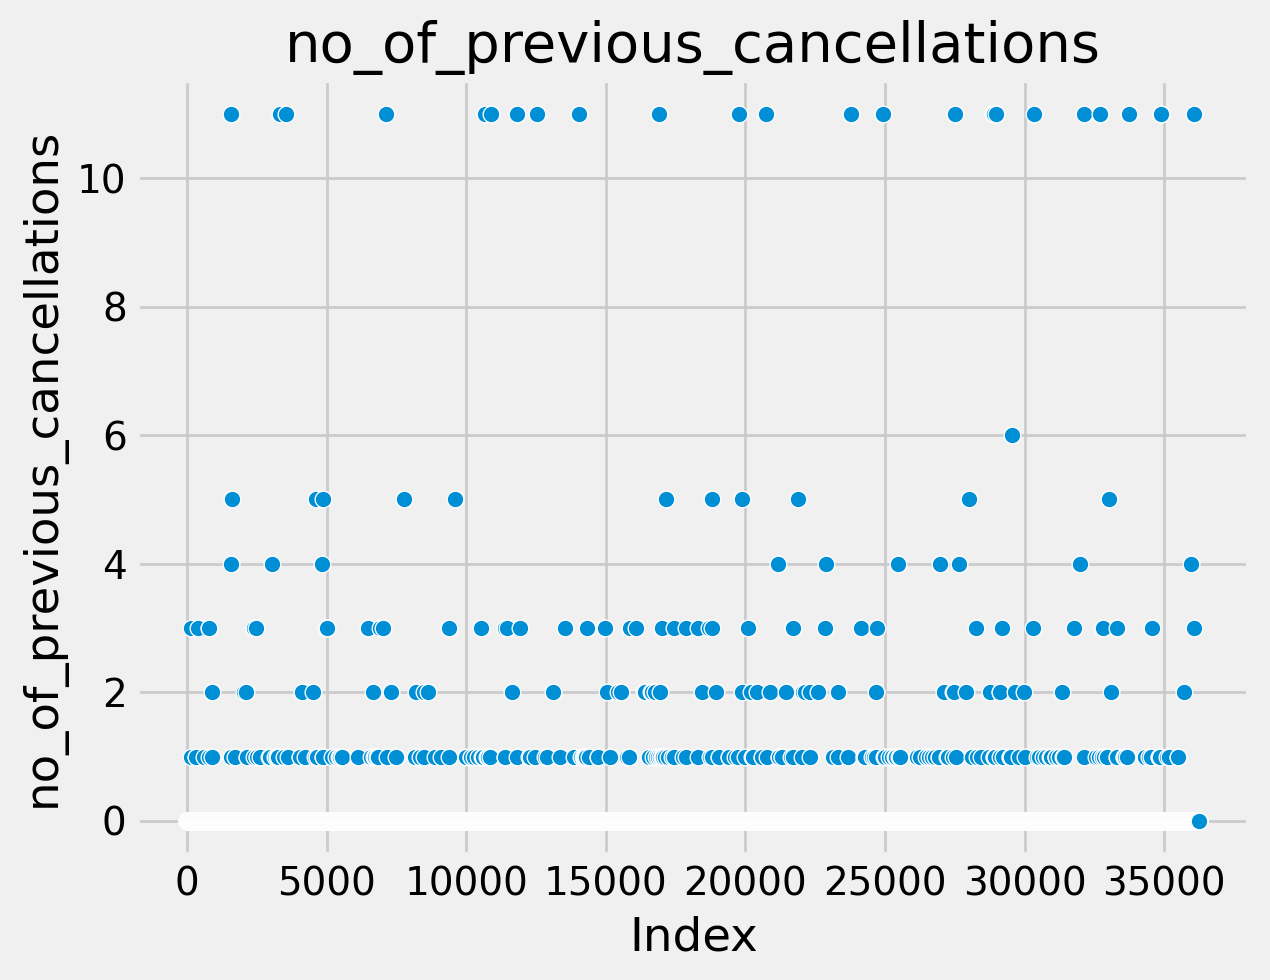

In [ ]:
sns.scatterplot(x=range(len(df)), y=df['no_of_previous_cancellations'])
plt.title('no_of_previous_cancellations')
plt.xlabel('Index')
plt.ylabel('no_of_previous_cancellations')

<Axes: xlabel='no_of_previous_cancellations', ylabel='count'>

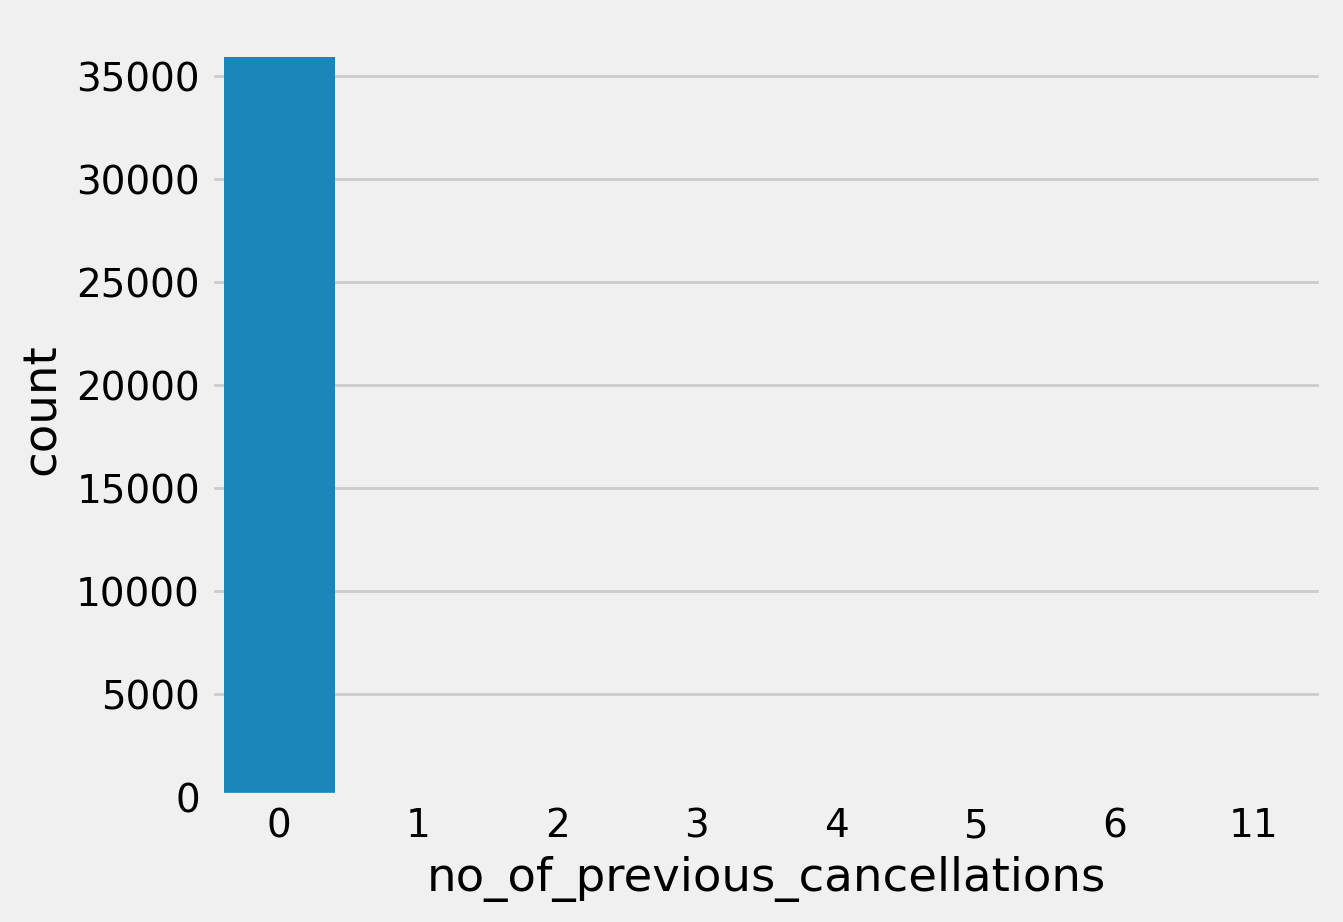

In [ ]:
sns.countplot(data=df, x="no_of_previous_cancellations")

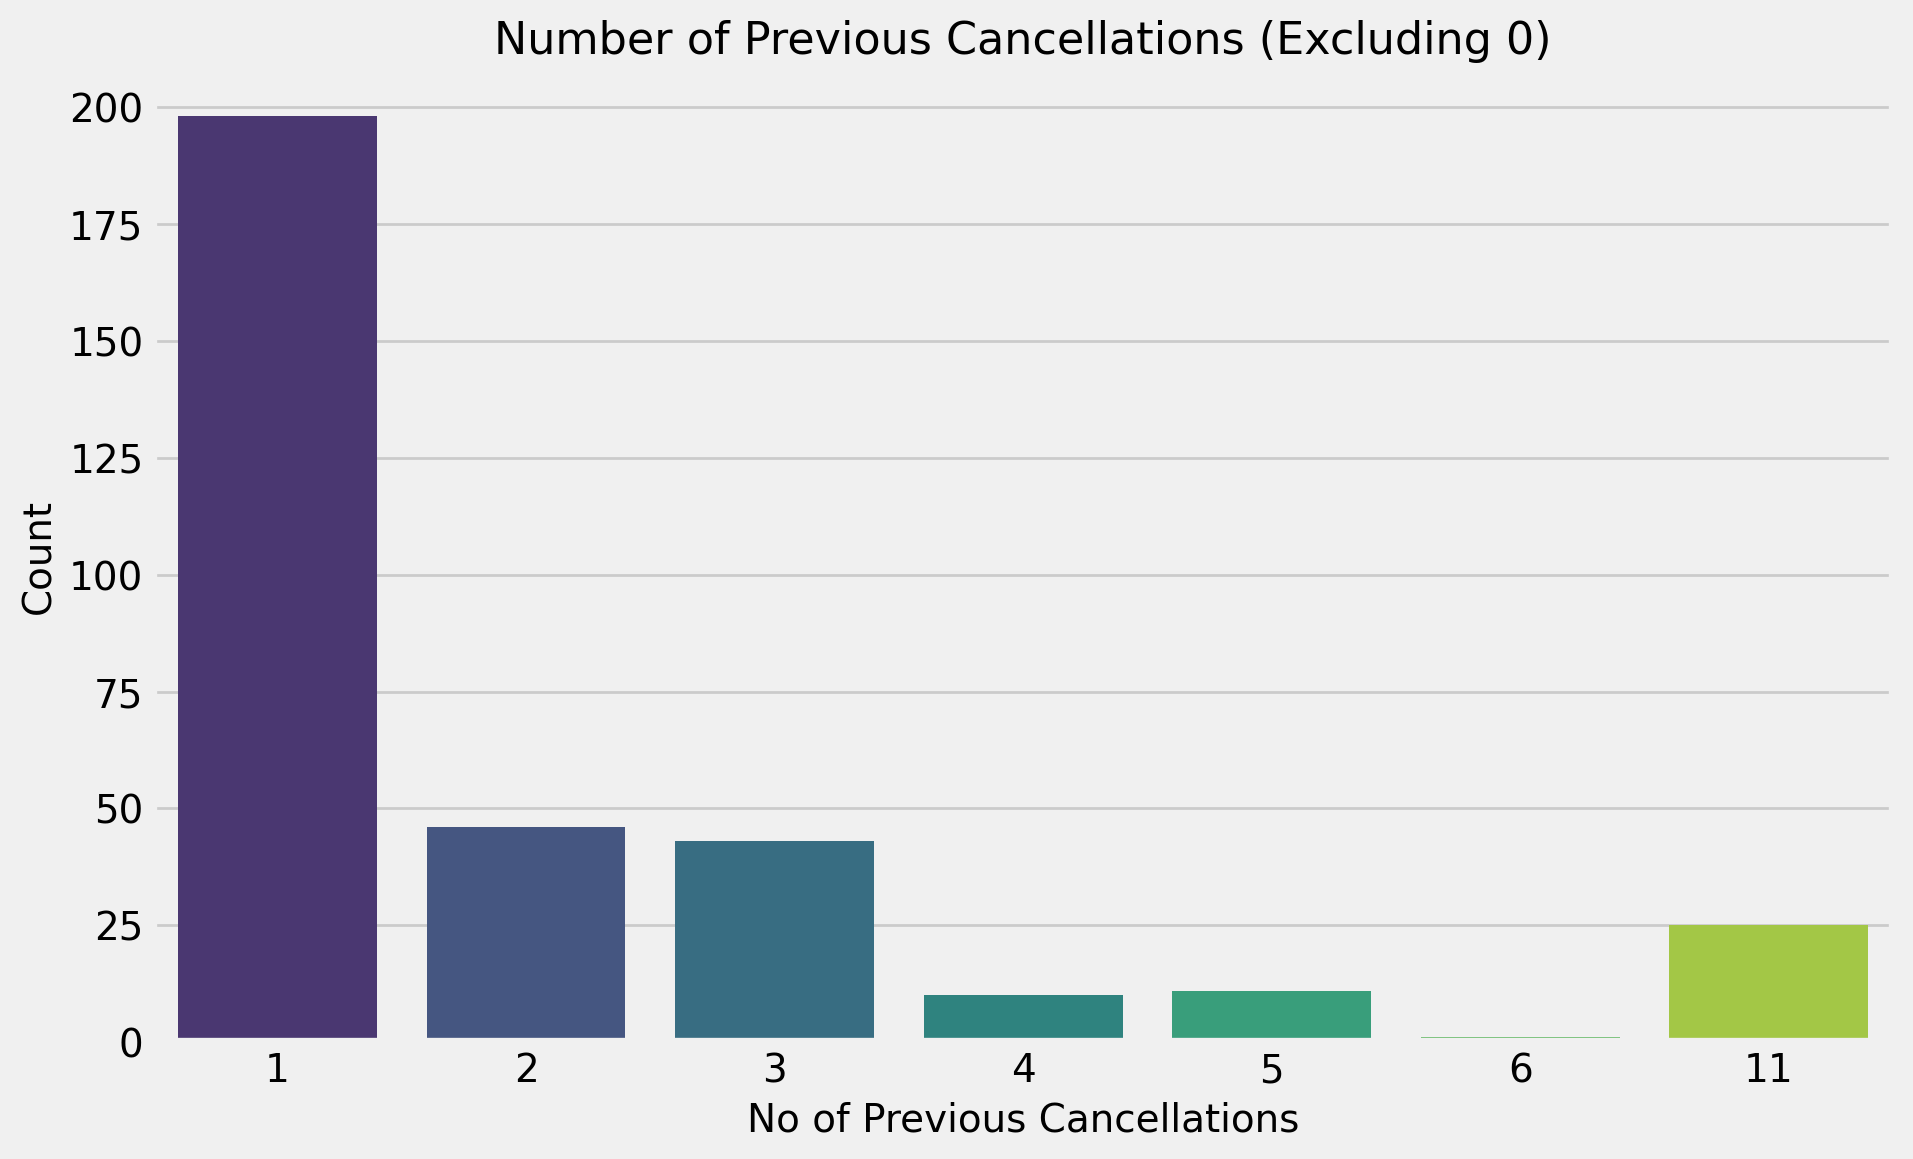

In [ ]:
filtered_df = df[df['no_of_previous_cancellations'] > 0]

# 그래프 크기 설정
plt.figure(figsize=(10, 6))

# 0을 제외한 no_of_previous_cancellations의 빈도 분포를 시각화
sns.countplot(x='no_of_previous_cancellations', data=filtered_df, palette='viridis')

# 그래프 제목과 레이블 설정
plt.title('Number of Previous Cancellations (Excluding 0)', fontsize=16)
plt.xlabel('No of Previous Cancellations', fontsize=14)
plt.ylabel('Count', fontsize=14)

# 그래프 표시
plt.show()

Text(0, 0.5, 'no_of_previous_bookings_not_canceled')

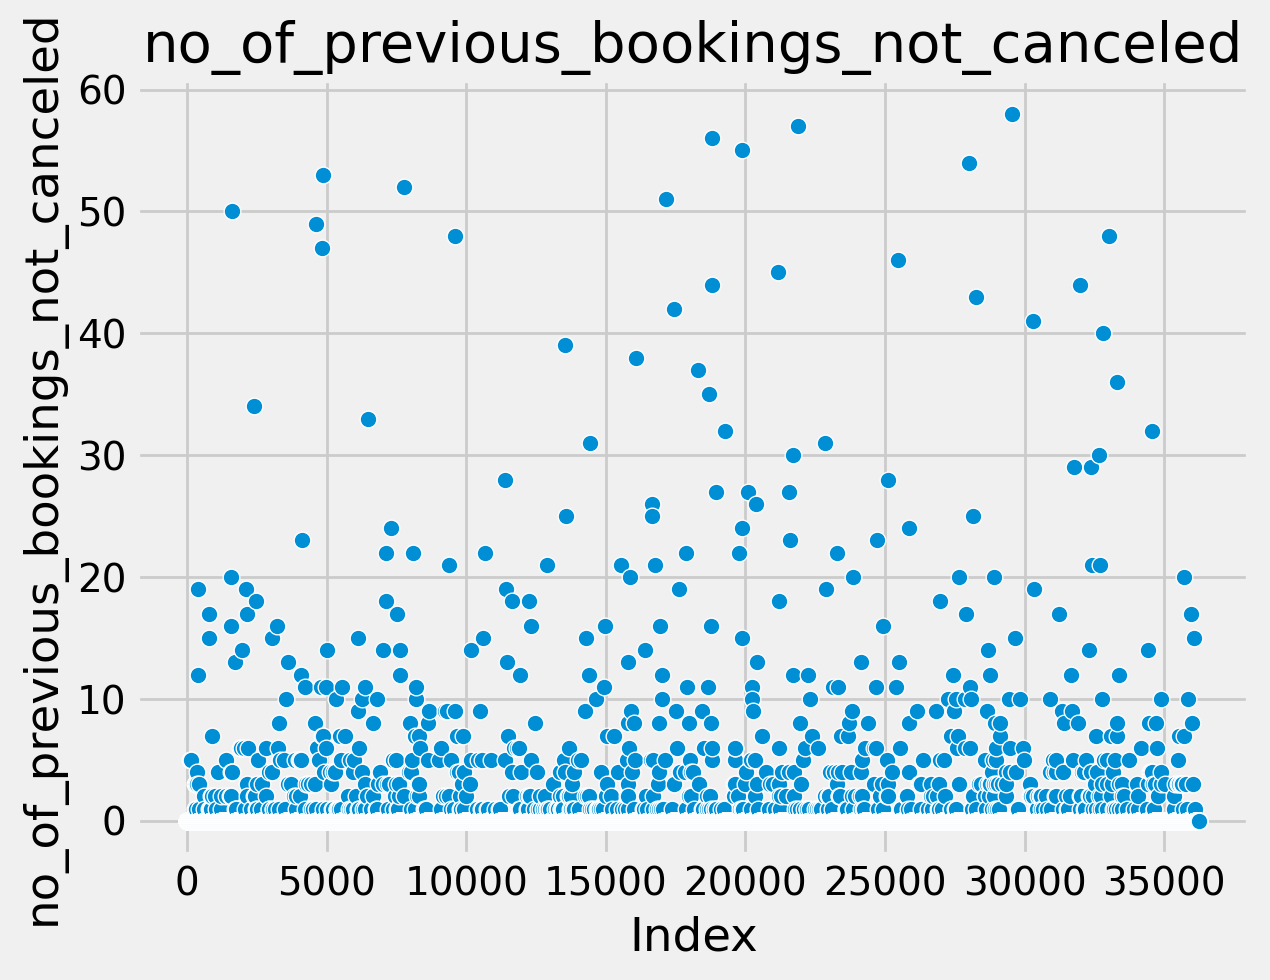

In [ ]:
sns.scatterplot(x=range(len(df)), y=df['no_of_previous_bookings_not_canceled'])
plt.title('no_of_previous_bookings_not_canceled')
plt.xlabel('Index')
plt.ylabel('no_of_previous_bookings_not_canceled')

(array([3.60e+04, 1.36e+02, 4.90e+01, 3.30e+01, 1.30e+01, 1.00e+01,
        6.00e+00, 7.00e+00, 7.00e+00, 6.00e+00]),
 array([ 0. ,  5.8, 11.6, 17.4, 23.2, 29. , 34.8, 40.6, 46.4, 52.2, 58. ]),
 <BarContainer object of 10 artists>)

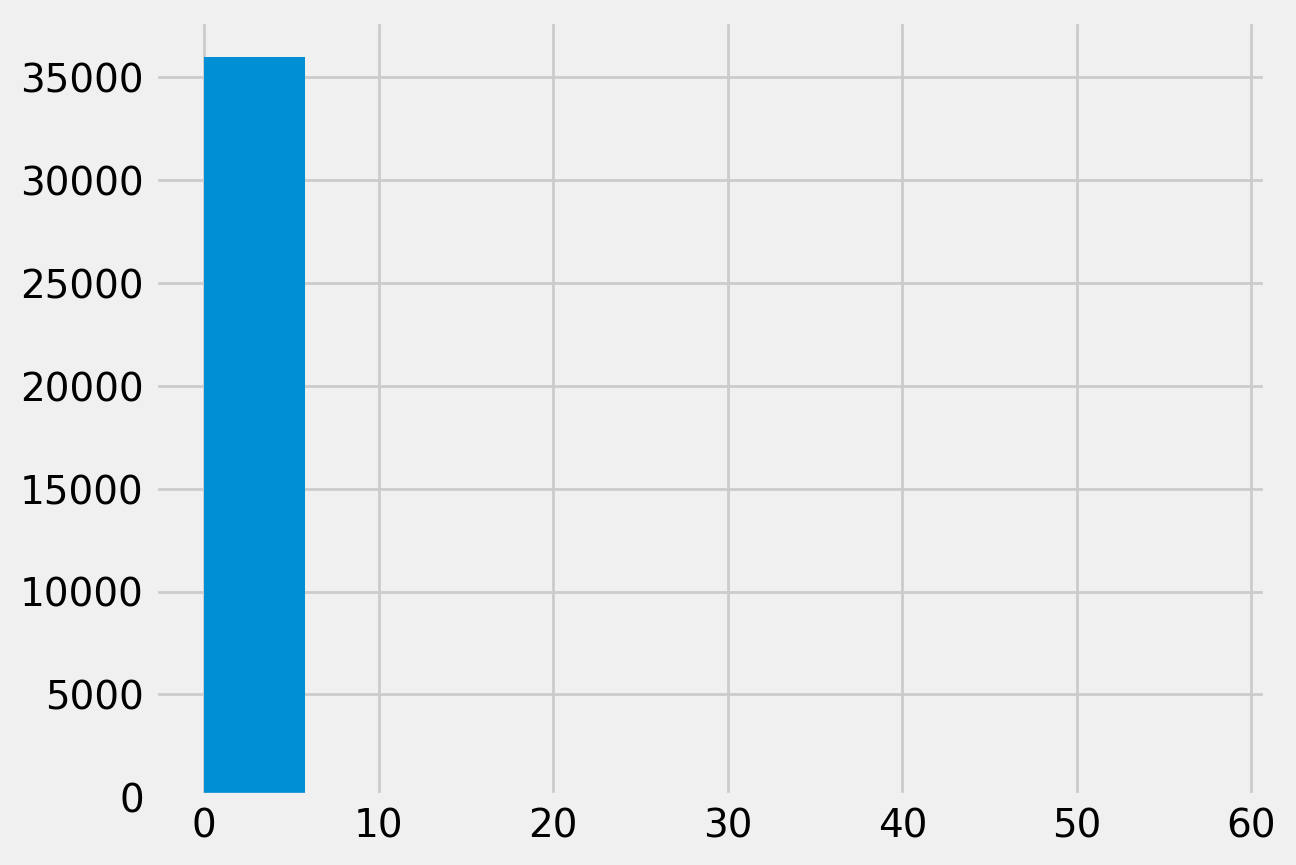

In [ ]:
plt.hist(data=df, x="no_of_previous_bookings_not_canceled")

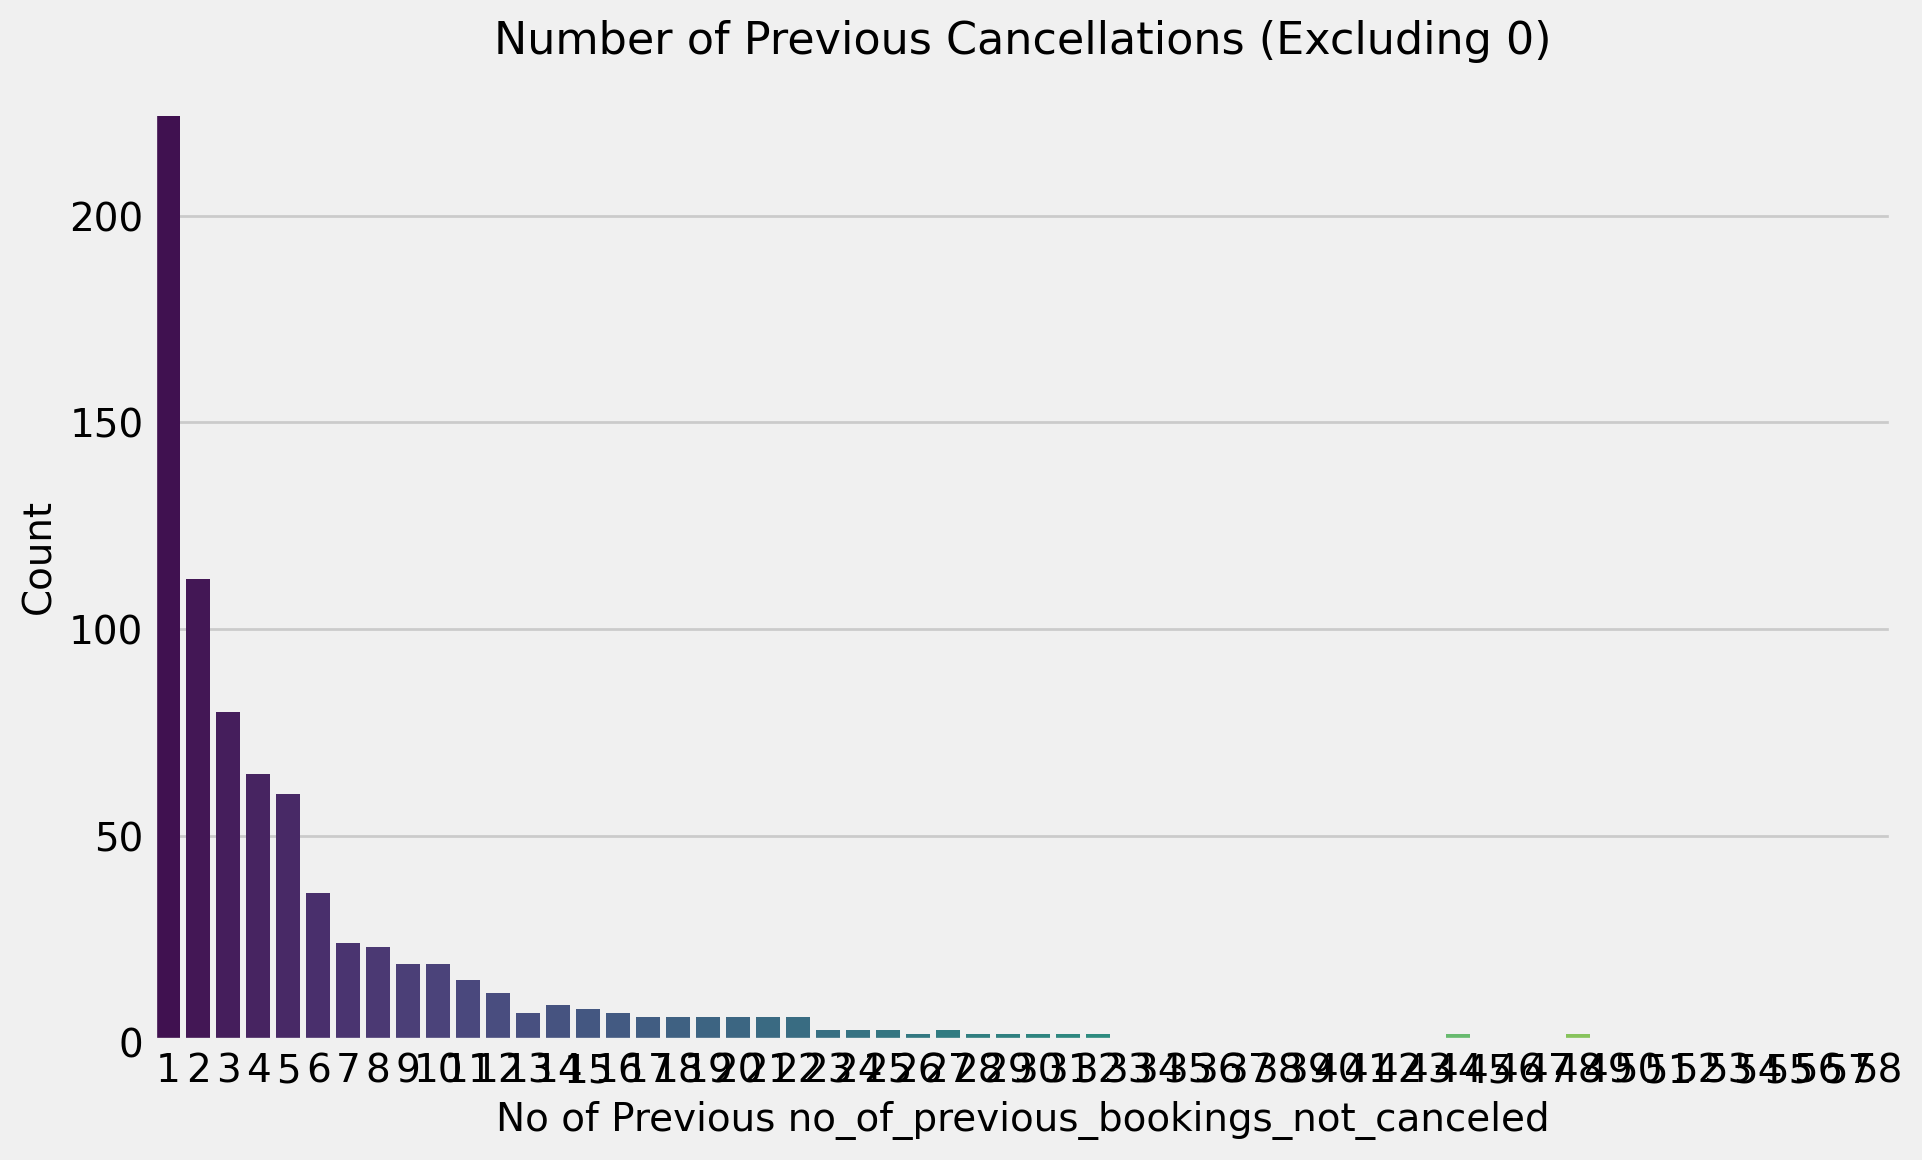

In [ ]:
filtered_df = df[df['no_of_previous_bookings_not_canceled'] > 0]

# 그래프 크기 설정
plt.figure(figsize=(10, 6))

# 0을 제외한 no_of_previous_cancellations의 빈도 분포를 시각화
sns.countplot(x='no_of_previous_bookings_not_canceled', data=filtered_df, palette='viridis')

# 그래프 제목과 레이블 설정
plt.title('Number of Previous Cancellations (Excluding 0)', fontsize=16)
plt.xlabel('No of Previous no_of_previous_bookings_not_canceled', fontsize=14)
plt.ylabel('Count', fontsize=14)

# 그래프 표시
plt.show()

In [ ]:
# df.info()

In [ ]:
df['total_guests'] = df['no_of_adults'] + df['no_of_children']

In [ ]:
df

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,...,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,total_guests,total_stay
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,...,2,Offline,0,0,0,65.00,0,Not_Canceled,2,3
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,...,6,Online,0,0,0,106.68,1,Not_Canceled,2,5
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,...,28,Online,0,0,0,60.00,0,Canceled,1,3
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,...,20,Online,0,0,0,100.00,0,Canceled,2,2
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,...,11,Online,0,0,0,94.50,0,Canceled,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36270,INN36271,3,0,2,6,Meal Plan 1,0,Room_Type 4,85,2018,...,3,Online,0,0,0,167.80,1,Not_Canceled,3,8
36271,INN36272,2,0,1,3,Meal Plan 1,0,Room_Type 1,228,2018,...,17,Online,0,0,0,90.95,2,Canceled,2,4
36272,INN36273,2,0,2,6,Meal Plan 1,0,Room_Type 1,148,2018,...,1,Online,0,0,0,98.39,2,Not_Canceled,2,8
36273,INN36274,2,0,0,3,Not Selected,0,Room_Type 1,63,2018,...,21,Online,0,0,0,94.50,0,Canceled,2,3


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36267 entries, 0 to 36274
Data columns (total 21 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36267 non-null  object 
 1   no_of_adults                          36267 non-null  int64  
 2   no_of_children                        36267 non-null  int64  
 3   no_of_weekend_nights                  36267 non-null  int64  
 4   no_of_week_nights                     36267 non-null  int64  
 5   type_of_meal_plan                     36267 non-null  object 
 6   required_car_parking_space            36267 non-null  int64  
 7   room_type_reserved                    36267 non-null  object 
 8   lead_time                             36267 non-null  int64  
 9   arrival_year                          36267 non-null  int64  
 10  arrival_month                         36267 non-null  int64  
 11  arrival_date        

In [ ]:
# df = df.drop(columns=Booking_ID)

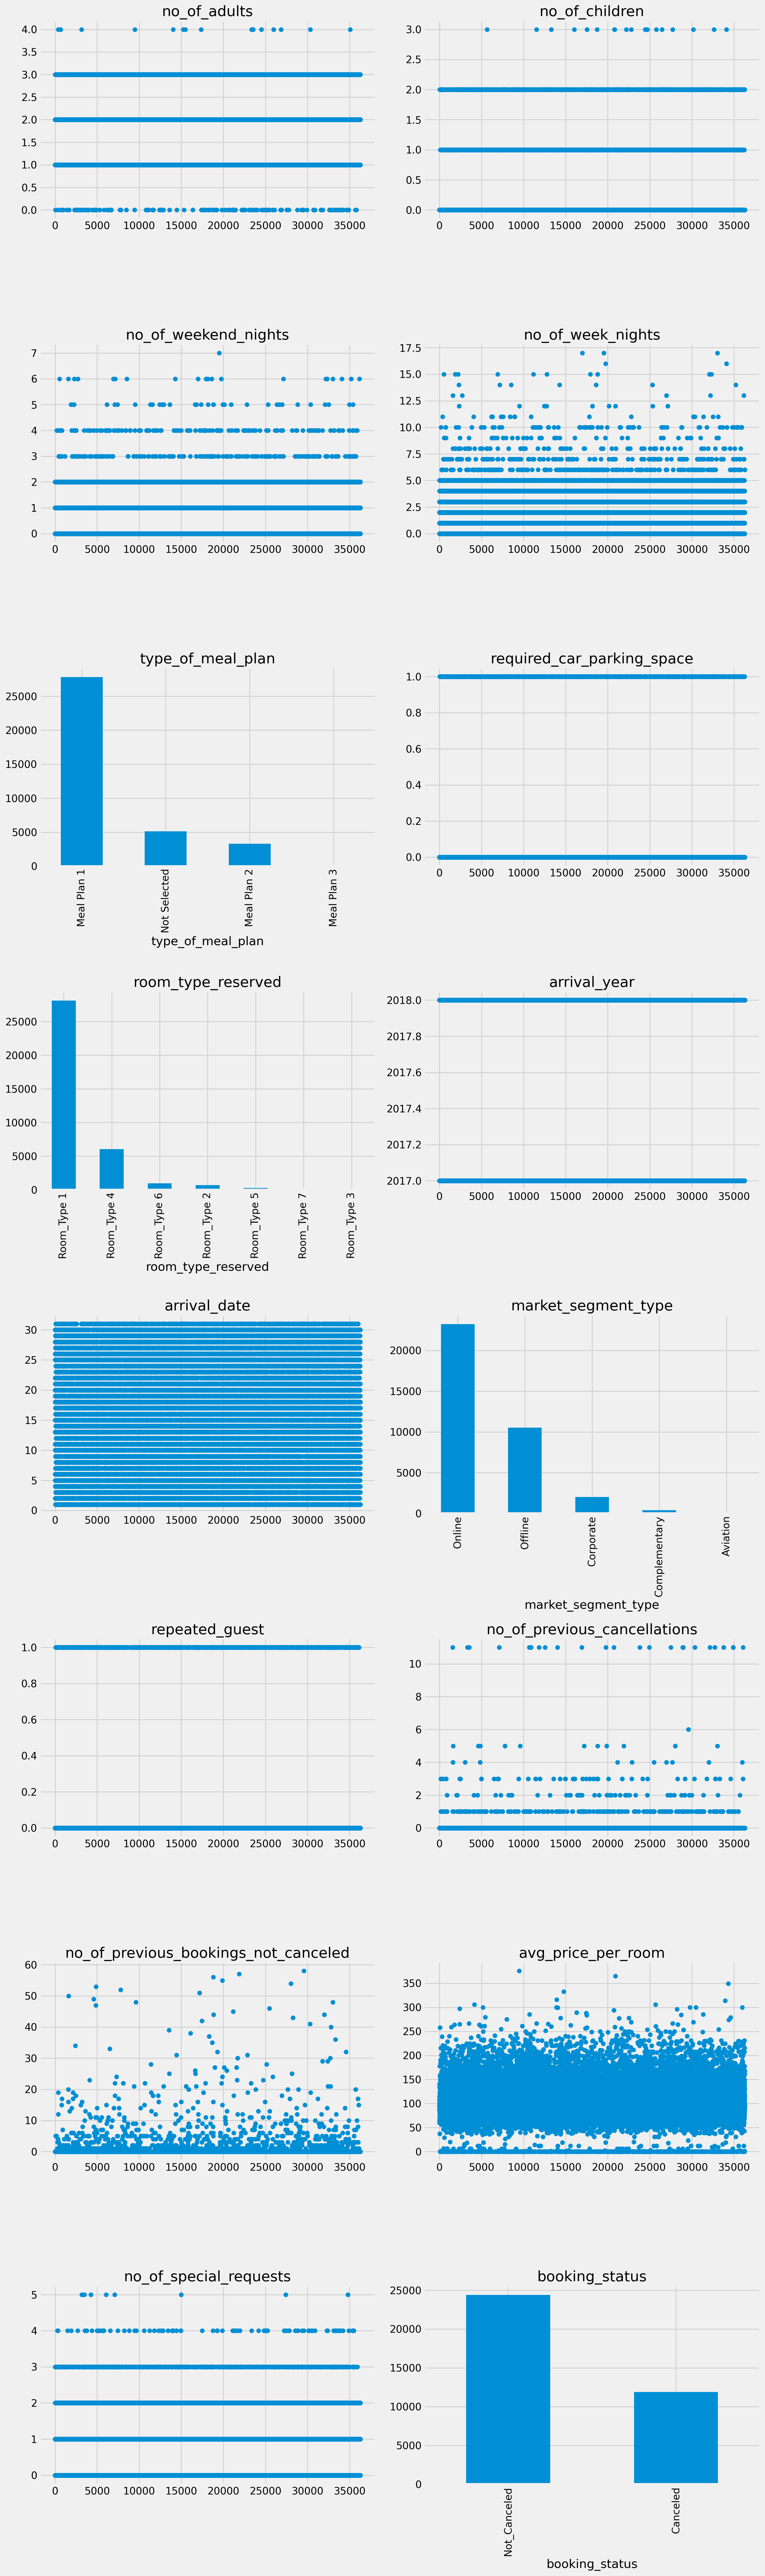

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


# 플롯할 컬럼 리스트
features = ['no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights',
            'type_of_meal_plan', 'required_car_parking_space', 'room_type_reserved',
            'arrival_year', 'arrival_date', 'market_segment_type', 'repeated_guest',
            'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
            'avg_price_per_room', 'no_of_special_requests', 'booking_status']

# 서브플롯 만들기
fig, axes = plt.subplots(nrows=8, ncols=2, figsize=(15, 50))
axes = axes.flatten()  # 2D array를 1D array로 바꿔서 접근하기 쉽게 만듦

# 각 피처별로 그래프 그리기
for i, feature in enumerate(features):
    if df[feature].dtype == 'object':
        df[feature].value_counts().plot(kind='bar', ax=axes[i], title=feature)
    else:
        axes[i].scatter(df.index, df[feature])
        axes[i].set_title(feature)

# 레이아웃 조정
plt.tight_layout()
plt.show()


## 인코딩(범주형>수치형)
(인코딩 전과 후를 비교하려 했더니, room_type_reserved가 이진변수가 아니라 할 수 없음)
-> 인코딩 먼저 , 통계검증 나중


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36267 entries, 0 to 36274
Data columns (total 21 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36267 non-null  object 
 1   no_of_adults                          36267 non-null  int64  
 2   no_of_children                        36267 non-null  int64  
 3   no_of_weekend_nights                  36267 non-null  int64  
 4   no_of_week_nights                     36267 non-null  int64  
 5   type_of_meal_plan                     36267 non-null  object 
 6   required_car_parking_space            36267 non-null  int64  
 7   room_type_reserved                    36267 non-null  object 
 8   lead_time                             36267 non-null  int64  
 9   arrival_year                          36267 non-null  int64  
 10  arrival_month                         36267 non-null  int64  
 11  arrival_date        

이진변수들(required_car_parking_space, repeated_guest)이 int64 인것으로 보아 이미 인코딩이 된 상태인듯.

그 외의 object변수들을 인코딩

In [ ]:
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,...,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,total_guests,total_stay
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,...,2,Offline,0,0,0,65.00,0,Not_Canceled,2,3
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,...,6,Online,0,0,0,106.68,1,Not_Canceled,2,5
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,...,28,Online,0,0,0,60.00,0,Canceled,1,3
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,...,20,Online,0,0,0,100.00,0,Canceled,2,2
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,...,11,Online,0,0,0,94.50,0,Canceled,2,2


In [ ]:
# 범주형 변수를 라벨인코딩
# 원-핫 인코딩 시 변수가 너무 많아질 것을 고려 + 이후에 상관성이나 왜도를 처리 할 때 그래프를 그릴 것을 고려
import pandas as pd

# 라벨 인코딩할 변수 리스트
columns_to_encode = ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type', 'booking_status']

# 여러 열에 대해 라벨 인코딩 적용
for col in columns_to_encode:
    df[col], _ = pd.factorize(df[col])

print(df)


      Booking_ID  no_of_adults  no_of_children  no_of_weekend_nights  \
0       INN00001             2               0                     1   
1       INN00002             2               0                     2   
2       INN00003             1               0                     2   
3       INN00004             2               0                     0   
4       INN00005             2               0                     1   
...          ...           ...             ...                   ...   
36270   INN36271             3               0                     2   
36271   INN36272             2               0                     1   
36272   INN36273             2               0                     2   
36273   INN36274             2               0                     0   
36274   INN36275             2               0                     1   

       no_of_week_nights  type_of_meal_plan  required_car_parking_space  \
0                      2                  0                 

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36267 entries, 0 to 36274
Data columns (total 21 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36267 non-null  object 
 1   no_of_adults                          36267 non-null  int64  
 2   no_of_children                        36267 non-null  int64  
 3   no_of_weekend_nights                  36267 non-null  int64  
 4   no_of_week_nights                     36267 non-null  int64  
 5   type_of_meal_plan                     36267 non-null  int64  
 6   required_car_parking_space            36267 non-null  int64  
 7   room_type_reserved                    36267 non-null  int64  
 8   lead_time                             36267 non-null  int64  
 9   arrival_year                          36267 non-null  int64  
 10  arrival_month                         36267 non-null  int64  
 11  arrival_date        

In [ ]:
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,...,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,total_guests,total_stay
0,INN00001,2,0,1,2,0,0,0,224,2017,...,2,0,0,0,0,65.00,0,0,2,3
1,INN00002,2,0,2,3,1,0,0,5,2018,...,6,1,0,0,0,106.68,1,0,2,5
2,INN00003,1,0,2,1,0,0,0,1,2018,...,28,1,0,0,0,60.00,0,1,1,3
3,INN00004,2,0,0,2,0,0,0,211,2018,...,20,1,0,0,0,100.00,0,1,2,2
4,INN00005,2,0,1,1,1,0,0,48,2018,...,11,1,0,0,0,94.50,0,1,2,2


In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns # Import seaborn for KDE plotting

# # 왜도와 첨도를 살펴볼 수 있는 연속형 데이터의 히스토그램 그리기
# numerical_features = ["lead_time","arrival_month","avg_price_per_room"]

# for feature in numerical_features:
#   plt.figure(figsize=(8, 6))

#   # Plot histogram
#   plt.hist(df[feature], bins=30, density=True) # Changed KDE="True" to density=True

#   # Overlay KDE plot using seaborn
#   sns.kdeplot(df[feature], color='red') # Added KDE plot

#   plt.title(f'{feature} Histogram')
#   plt.xlabel(feature)
#   plt.ylabel('Frequency')
#   plt.show()

In [ ]:
df["lead_time"].dtype

dtype('int64')

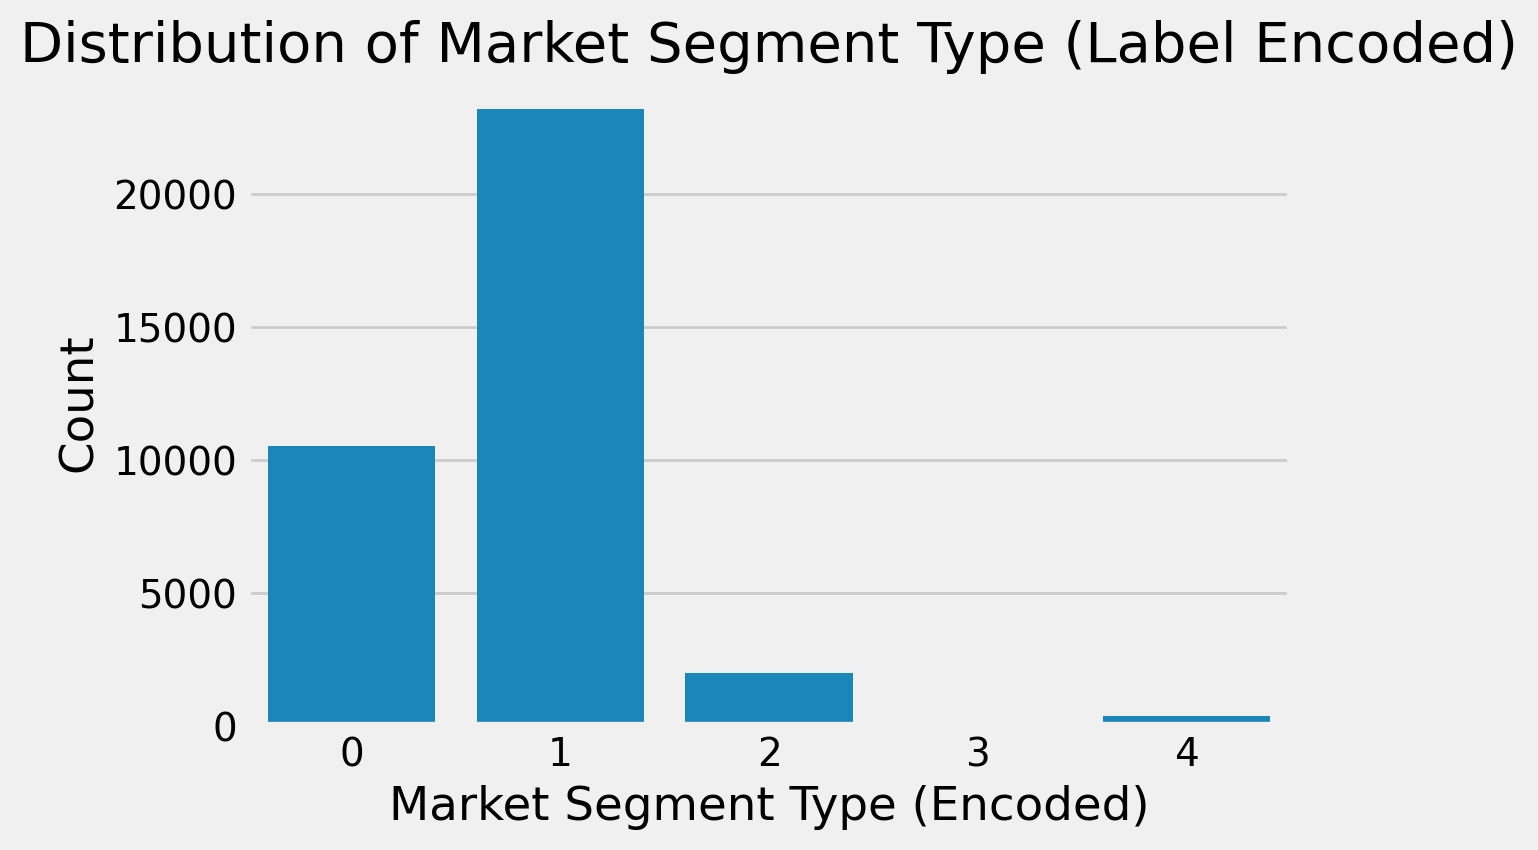

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='market_segment_type', data=df)
plt.title('Distribution of Market Segment Type (Label Encoded)')
plt.xlabel('Market Segment Type (Encoded)')
plt.ylabel('Count')
plt.show()

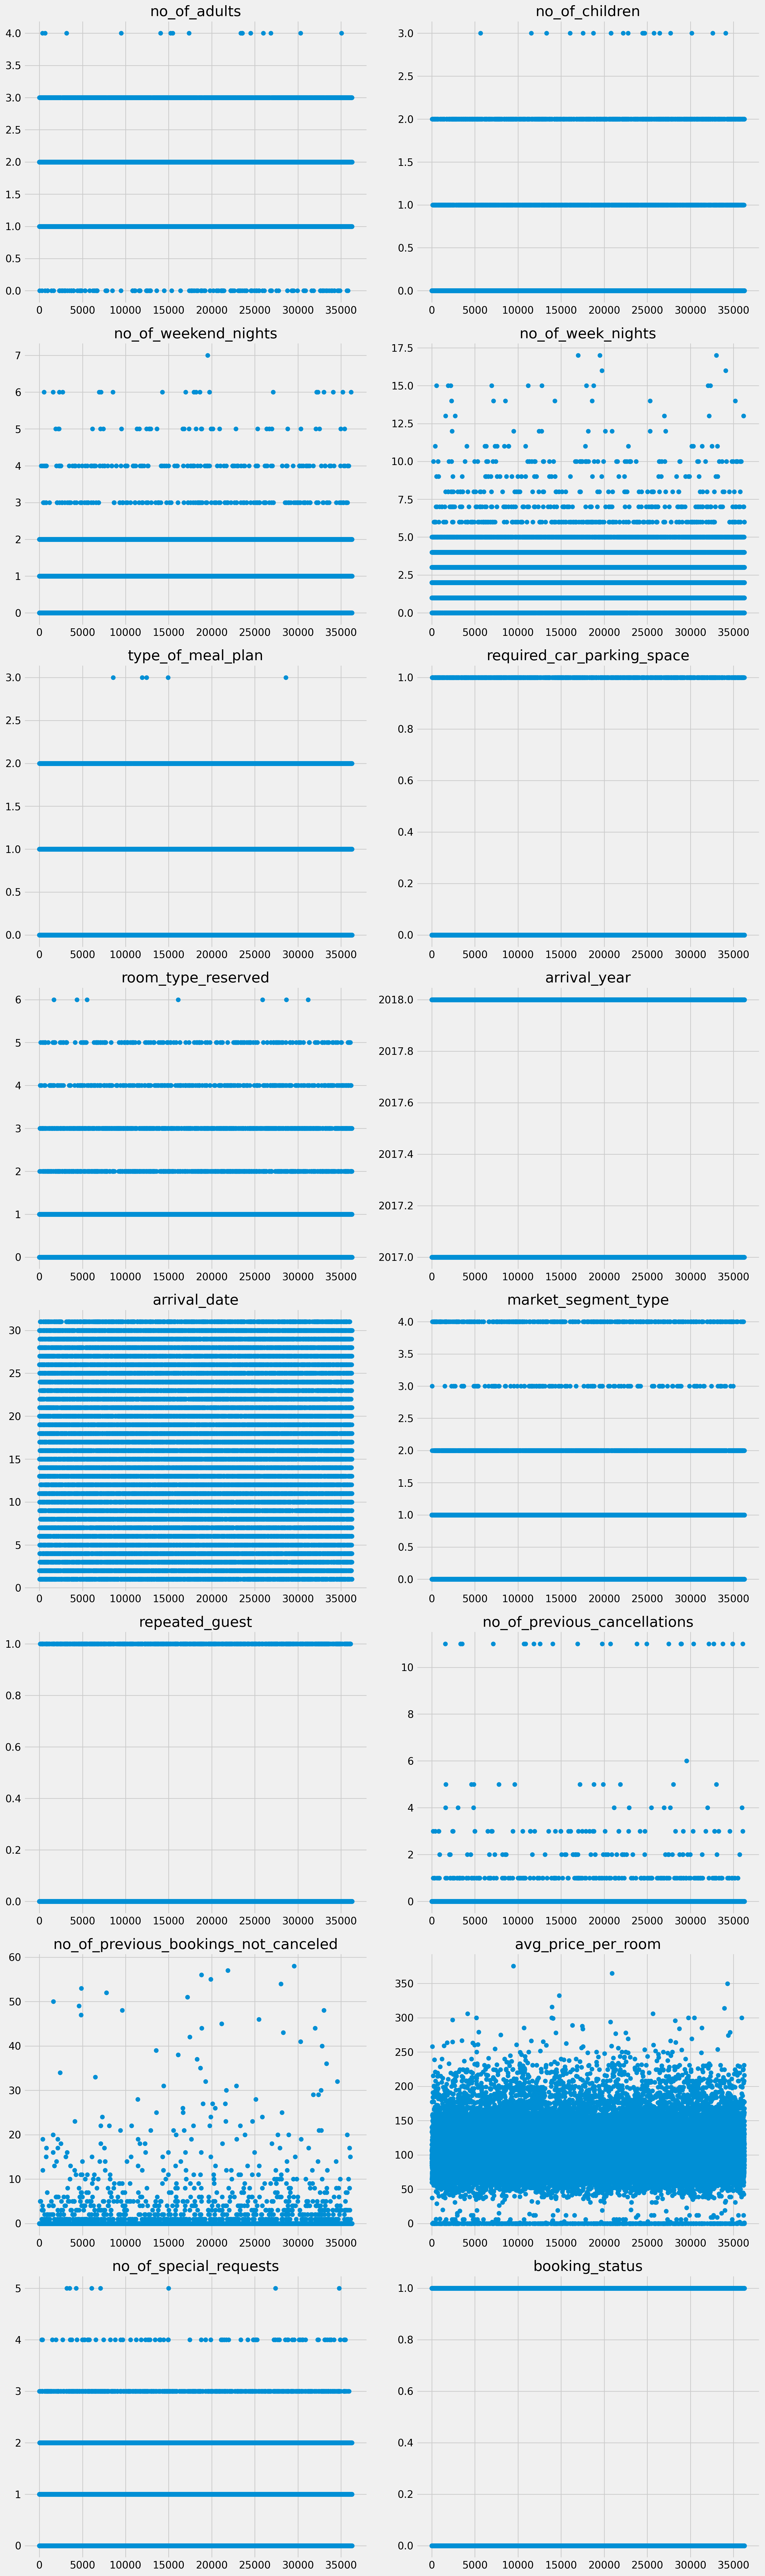

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


# 플롯할 컬럼 리스트
features = ['no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights',
            'type_of_meal_plan', 'required_car_parking_space', 'room_type_reserved',
            'arrival_year', 'arrival_date', 'market_segment_type', 'repeated_guest',
            'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
            'avg_price_per_room', 'no_of_special_requests', 'booking_status']

# 서브플롯 만들기
fig, axes = plt.subplots(nrows=8, ncols=2, figsize=(15, 50))
axes = axes.flatten()  # 2D array를 1D array로 바꿔서 접근하기 쉽게 만듦

# 각 피처별로 그래프 그리기
for i, feature in enumerate(features):
    if df[feature].dtype == 'object':
        df[feature].value_counts().plot(kind='bar', ax=axes[i], title=feature)
    else:
        axes[i].scatter(df.index, df[feature])
        axes[i].set_title(feature)

# 레이아웃 조정
plt.tight_layout()
plt.show()


##통계적검증

### 수치형 변수

In [ ]:
# 수치형 변수 선택
numerical_cols = ['lead_time', 'no_of_previous_cancellations',
                  'no_of_previous_bookings_not_canceled', 'avg_price_per_room',
                  'no_of_special_requests', 'total_stay', 'total_guest']

# 상관계수 계산
correlation = df[['room_type_encoded'] + numerical_cols].corr()

# 룸 타입과 다른 변수들 간의 상관관계만 선택
room_type_corr = correlation.loc['room_type_encoded', numerical_cols]
print(room_type_corr)

KeyError: "['room_type_encoded', 'total_guest'] not in index"

### 연속형 변수와의 상관성

In [ ]:
from scipy.stats import pointbiserialr

# 연속형 변수 목록
continuous_columns = ['avg_price_per_room', 'lead_time',"arrival_month"]

# 각 변수에 대해 상관계수와 p-value를 계산하고 출력
for col in continuous_columns:
    corr, p_value = pointbiserialr(df['room_type_reserved'], df[col])
    print(f"{col} - Point-Biserial Correlation: {corr:.2f}, p-value: {p_value:.4f}")

avg_price_per_room - Point-Biserial Correlation: 0.41, p-value: 0.0000
lead_time - Point-Biserial Correlation: -0.09, p-value: 0.0000
arrival_month - Point-Biserial Correlation: -0.00, p-value: 0.4227


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols

continuous_columns = ['avg_price_per_room', 'lead_time', 'arrival_month']
categorical_column = 'room_type_reserved'

# 결과를 저장할 리스트 생성
results = []

# 각 연속형 변수에 대해 ANOVA 수행
for col in continuous_columns:
    model = ols(f'{col} ~ C({categorical_column})', data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    results.append({
        '연속형변수': col,
        'F-통계량': anova_table['F'][0],
        'p-값': anova_table['PR(>F)'][0]
    })

# 결과를 데이터프레임으로 변환
results_df = pd.DataFrame(results)

# 결과 출력
print(results_df)

print(results_df)

                연속형변수        F-통계량           p-값
0  avg_price_per_room  2031.926492  0.000000e+00
1           lead_time    77.336331  2.003498e-96
2       arrival_month     4.694158  8.783085e-05
                연속형변수        F-통계량           p-값
0  avg_price_per_room  2031.926492  0.000000e+00
1           lead_time    77.336331  2.003498e-96
2       arrival_month     4.694158  8.783085e-05


**Point-Biserial 상관계수 활용 결과:room_type_reserved와 avg_price_per_room간의 약한 상관성을 확인**

**ANOVA 활용결과 : 'avg_price_per_room', 'lead_time' 이 모두 유의미한 상관성이 있는 것을 확인**

###범주형 변수간의 상관성 검증

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency


# 교차표 생성
cross_tab = pd.crosstab(df['room_type_reserved'], df['type_of_meal_plan'])

# Cramér's V 계산 함수 정의
def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = np.sum(confusion_matrix)
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k - 1, r - 1))

# Cramér's V 계산
cramer_v_value = cramers_v(cross_tab.values)
print(f"Cramér's V: {cramer_v_value}")


Cramér's V: 0.14698855784227627


In [ ]:
def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = np.sum(confusion_matrix)
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k - 1, r - 1))

results = {}
categorical_vars = ['no_of_adults', 'no_of_children', 'no_of_weekend_nights','no_of_week_nights','no_of_previous_cancellations','no_of_previous_bookings_not_canceled','no_of_special_requests']  # 비교할 변수들

for var in categorical_vars:
    cross_tab = pd.crosstab(df['room_type_reserved'], df[var])
    cramer_v_value = cramers_v(cross_tab.values)
    results[var] = cramer_v_value

# 결과 출력
results_df = pd.DataFrame(list(results.items()), columns=['Variable', "Cramér's V"])
print(results_df)

                               Variable  Cramér's V
0                          no_of_adults    0.329293
1                        no_of_children    0.469677
2                  no_of_weekend_nights    0.033237
3                     no_of_week_nights    0.055967
4          no_of_previous_cancellations    0.056307
5  no_of_previous_bookings_not_canceled    0.062859
6                no_of_special_requests    0.076501


In [ ]:
df['total_guests'] = df['no_of_children'] + df['no_of_adults']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36267 entries, 0 to 36274
Data columns (total 21 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36267 non-null  object 
 1   no_of_adults                          36267 non-null  int64  
 2   no_of_children                        36267 non-null  int64  
 3   no_of_weekend_nights                  36267 non-null  int64  
 4   no_of_week_nights                     36267 non-null  int64  
 5   type_of_meal_plan                     36267 non-null  int64  
 6   required_car_parking_space            36267 non-null  int64  
 7   room_type_reserved                    36267 non-null  int64  
 8   lead_time                             36267 non-null  int64  
 9   arrival_year                          36267 non-null  int64  
 10  arrival_month                         36267 non-null  int64  
 11  arrival_date        

In [ ]:
cross_tab = pd.crosstab(df['room_type_reserved'], df['total_guests'])

# Cramér's V 계산 함수 정의
def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = np.sum(confusion_matrix)
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k - 1, r - 1))

# Cramér's V 계산
cramer_v_value = cramers_v(cross_tab.values)
print(f"Cramér's V: {cramer_v_value}")

Cramér's V: 0.4502512425660917


cramer값이 너무 낮아서 카이제곱으로 다시 실시

In [ ]:

from scipy.stats import chi2_contingency

room_meal = pd.crosstab(df['type_of_meal_plan'], df['room_type_reserved'])

chi2, p, dof, expected = chi2_contingency(room_meal)
print(f"Chi-square: {chi2}, p-value: {p}")

Chi-square: 2350.714817293015, p-value: 0.0


In [ ]:

from scipy.stats import chi2_contingency

room_adult = pd.crosstab(df['no_of_adults'], df['room_type_reserved'])

chi2, p, dof, expected = chi2_contingency(room_adult)
print(f"Chi-square: {chi2}, p-value: {p}")

Chi-square: 15730.32951359983, p-value: 0.0


In [ ]:

from scipy.stats import chi2_contingency

room_market = pd.crosstab(df['market_segment_type'], df['room_type_reserved'])

chi2, p, dof, expected = chi2_contingency(room_market)
print(f"Chi-square: {chi2}, p-value: {p}")

Chi-square: 3947.530273384714, p-value: 0.0


In [ ]:

from scipy.stats import chi2_contingency

room_child = pd.crosstab(df['no_of_children'], df['room_type_reserved'])

chi2, p, dof, expected = chi2_contingency(room_child)
print(f"Chi-square: {chi2}, p-value: {p}")

Chi-square: 24001.102509637865, p-value: 0.0


In [ ]:

from scipy.stats import chi2_contingency

room_total_guests = pd.crosstab(df['total_guests'], df['room_type_reserved'])

chi2, p, dof, expected = chi2_contingency(room_total_guests)
print(f"Chi-square: {chi2}, p-value: {p}")

Chi-square: 29409.081688022285, p-value: 0.0


In [ ]:

from scipy.stats import chi2_contingency

room_weekend = pd.crosstab(df['no_of_weekend_nights'], df['room_type_reserved'])

chi2, p, dof, expected = chi2_contingency(room_weekend)
print(f"Chi-square: {chi2}, p-value: {p}")

Chi-square: 240.3847217599323, p-value: 1.232342312976361e-29


In [ ]:

from scipy.stats import chi2_contingency

room_week = pd.crosstab(df['no_of_week_nights'], df['room_type_reserved'])

chi2, p, dof, expected = chi2_contingency(room_week)
print(f"Chi-square: {chi2}, p-value: {p}")

Chi-square: 681.5929387647831, p-value: 1.6006804929998154e-86


In [ ]:
#weekend&week_nights는 다른 것들보다 비교적 약한 상관성인듯

In [ ]:
df['total_stay'] = df['no_of_weekend_nights'] + df['no_of_week_nights']

from scipy.stats import chi2_contingency

room_stay = pd.crosstab(df['total_stay'], df['room_type_reserved'])

chi2, p, dof, expected = chi2_contingency(room_stay)
print(f"Chi-square: {chi2}, p-value: {p}")

Chi-square: 925.0586414211814, p-value: 3.1150719007972105e-114


In [ ]:

from scipy.stats import chi2_contingency

room_prev_cancel = pd.crosstab(df['no_of_previous_cancellations'], df['room_type_reserved'])

chi2, p, dof, expected = chi2_contingency(room_prev_cancel)
print(f"Chi-square: {chi2}, p-value: {p}")

Chi-square: 689.8931662152336, p-value: 3.858094736886199e-118


In [ ]:

from scipy.stats import chi2_contingency

room_prev_booking = pd.crosstab(df['no_of_previous_bookings_not_canceled'], df['room_type_reserved'])

chi2, p, dof, expected = chi2_contingency(room_prev_booking)
print(f"Chi-square: {chi2}, p-value: {p}")

Chi-square: 859.806776064016, p-value: 3.3390034592758466e-45


In [ ]:
from scipy.stats import chi2_contingency

room_requests = pd.crosstab(df['no_of_special_requests'], df['room_type_reserved'])

chi2, p, dof, expected = chi2_contingency(room_requests)
print(f"Chi-square: {chi2}, p-value: {p}")

Chi-square: 1061.2471175094242, p-value: 5.9062134200277534e-204


In [ ]:
from scipy.stats import chi2_contingency

room_date= pd.crosstab(df['arrival_date'], df['room_type_reserved'])

chi2, p, dof, expected = chi2_contingency(room_date)
print(f"Chi-square: {chi2}, p-value: {p}")

Chi-square: 449.05854487360386, p-value: 5.635942293398754e-25


### 다중공선성 확인

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import LabelEncoder

# Label Encoding 적용
label_cols = ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type', 'booking_status']
label_encoders = {}

for col in label_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # 인코더 저장

# 수치형 변수와 인코딩된 범주형 변수로 구성된 데이터 사용
X = df.drop(columns=['Booking_ID'])  # Booking_ID는 분석에서 제외

# 각 변수의 VIF 계산
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

# VIF 값 출력
print(vif_data)

                                 Feature        VIF
0                           no_of_adults        inf
1                         no_of_children        inf
2                   no_of_weekend_nights        inf
3                      no_of_week_nights        inf
4                      type_of_meal_plan   1.358621
5             required_car_parking_space   1.072759
6                     room_type_reserved   1.838541
7                              lead_time   3.002377
8                           arrival_year  35.123681
9                          arrival_month   7.190618
10                          arrival_date   4.208423
11                   market_segment_type   3.499865
12                        repeated_guest   1.665895
13          no_of_previous_cancellations   1.392448
14  no_of_previous_bookings_not_canceled   1.664543
15                    avg_price_per_room  14.819028
16                no_of_special_requests   2.070524
17                        booking_status   2.193851
18          